# Arm 1 (`go_enrichment` v1) — full-dataset result

**Arm 1 is the no-LLM baseline**: a classical statistical test (following the method of the established
tool g:Profiler) that checks, for a gene's set of reliably-expressed cell types, which biological-process
GO terms are over-represented among them. No language model is involved anywhere in this arm — it is pure
statistics, run here across every one of the dataset's ~15,900 scoreable genes.

**Headline result, stated plainly up front:** of the GO terms this method flags as statistically
significant, **94% do not match the gene's own, independently-known GO annotation at all.** Only
**7.7% of genes** get even one real match, and only **1.2%** get an exact one. This notebook shows that
result from several angles and, in the last section, why it happens — the method is not broken, but it is
structurally limited to a narrow slice of genes (see `approaches/README.md` for the full methodology and
the earlier ceiling analysis this notebook's last plot draws on).

Every number plotted below is recomputed from the saved result files in this notebook, not hand-typed, so
it cannot silently drift from the underlying data.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = ROOT / "notebooks" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", font_scale=1.05)

# ---- ONE color code, reused in every plot below -----------------------------------------------
# Two separate palettes on purpose: a prediction's "outcome" (exact/upward/downward/no_match) is a
# different kind of thing from a plain count/volume, so they get visually distinct color families —
# this way a reader never mistakes a volume bar for an outcome-category bar.
COLORS = {
    # match-outcome palette (colorblind-safe, Okabe-Ito based)
    "exact":    "#009E73",  # green  -- the predicted term IS one of the gene's own annotated terms
    "upward":   "#0072B2",  # blue   -- the predicted term is a more GENERAL version of a true term
                            #           (reached by walking UP the GO graph from the true term)
    "downward": "#E69F00",  # orange -- the predicted term is a more SPECIFIC version of a true term
                            #           (reached by walking UP the GO graph from the prediction)
    "no_match": "#7F7F7F",  # grey   -- neither of the above: no informative relation found
    # plain volume/count palette -- used only for plots that are NOT about match outcome
    "volume":   "#4C72B0",  # single neutral blue, never reused for an outcome category
}
ORDER = ["exact", "upward", "downward", "no_match"]  # fixed left-to-right / top-to-bottom order everywhere

def save(fig, name: str) -> None:
    fig.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")

## Loading the results

- **`match_summary__go_enrichment_v1_positive__all.json`** — produced by `scripts/summarize_go_matches.py`
  on the full arm-1 run. For every gene, it classifies each of the gene's *significant* GO-term predictions
  (g:SCS-corrected p < 0.05 — the same significance threshold g:Profiler itself defaults to) against that
  gene's own, independently-known GO annotation:
    - **exact** — the predicted term literally IS one of the gene's annotated terms
    - **upward (generalisation)** — reached by walking UP the GO graph from a true term to the prediction
      (the prediction is a broader category that contains the truth, e.g. "phagocytosis, engulfment" (true)
      → "phagocytosis" (predicted), 1 step up)
    - **downward (specialisation)** — the reverse: walking up FROM the prediction reaches a true term (the
      prediction is a plausible, more specific guess that happens not to be separately annotated)
    - **no_match** — neither: no informative relation between the prediction and the truth
- **`go_ceiling_genes.tsv`** — a separate, earlier analysis: for each gene, the best score *any* method
  could possibly achieve using only this candidate-term vocabulary (`f1_top1`, the "oracle ceiling") and
  what a method would score by picking a term at random (`f1_top1_random`, the floor). Used only in the
  last plot, to explain *why* the result above looks the way it does.

In [2]:
RESULTS_DIR = ROOT / "data" / "go_experiment" / "match_summaries"
summary = json.loads((RESULTS_DIR / "match_summary__go_enrichment_v1_positive__all.json").read_text())

genes = pd.DataFrame(summary["per_gene"])
# sanity check: every gene's four outcome counts must add up to its own n_significant
assert (genes[["n_exact", "n_upward", "n_downward", "n_no_match"]].sum(axis=1) == genes["n_significant"]).all()

print(f"genes with a result:        {len(genes):,}")
print(f"significance threshold:     {summary['significance_basis']}")
print(f"total significant terms:    {summary['terms']['n_total']:,}")

genes with a result:        15,754
significance threshold:     p_gscs < 0.05 (g:SCS)
total significant terms:    26,779


## 1. Where does the gene population go? (funnel)

The most direct view of the attrition: starting from every gene that *could* be scored, how many make it
through each successive, stricter bar — getting any significant prediction at all, then getting a real
match, then getting an exact one. Nothing is hidden or reordered to look better; the bars simply shrink by
however much they shrink.

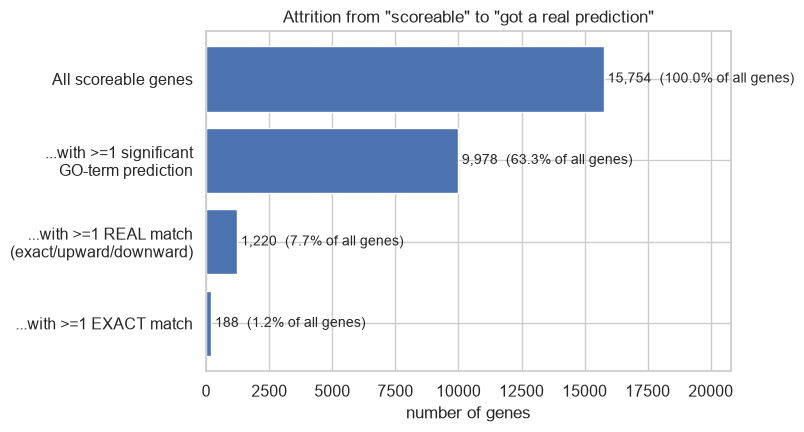

In [3]:
n_total = len(genes)
n_any_sig = (genes["n_significant"] > 0).sum()
n_any_match = ((genes["n_exact"] + genes["n_upward"] + genes["n_downward"]) > 0).sum()
n_any_exact = (genes["n_exact"] > 0).sum()

funnel = pd.Series(
    {
        "All scoreable genes": n_total,
        "...with >=1 significant\nGO-term prediction": n_any_sig,
        "...with >=1 REAL match\n(exact/upward/downward)": n_any_match,
        "...with >=1 EXACT match": n_any_exact,
    }
)

fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.barh(funnel.index[::-1], funnel.values[::-1], color=COLORS["volume"])
for bar, v in zip(bars, funnel.values[::-1]):
    ax.text(bar.get_width() + n_total * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{v:,}  ({v / n_total:.1%} of all genes)", va="center", fontsize=10)
ax.set_xlim(0, n_total * 1.32)
ax.set_xlabel("number of genes")
ax.set_title("Attrition from \"scoreable\" to \"got a real prediction\"")
fig.tight_layout()
save(fig, "01_funnel")
plt.show()

## 2. What happens to a significant term, once produced? (outcome breakdown)

This is a bar chart, **deliberately not a pie chart and not log-scaled**. A pie chart makes it genuinely
harder to read off precise shares when one slice is this dominant, and a log scale would visually compress
the very dominance this plot needs to show honestly — the point of this figure is specifically that
`no_match` is overwhelming, and a transform that shrinks that visual gap would misrepresent the result.

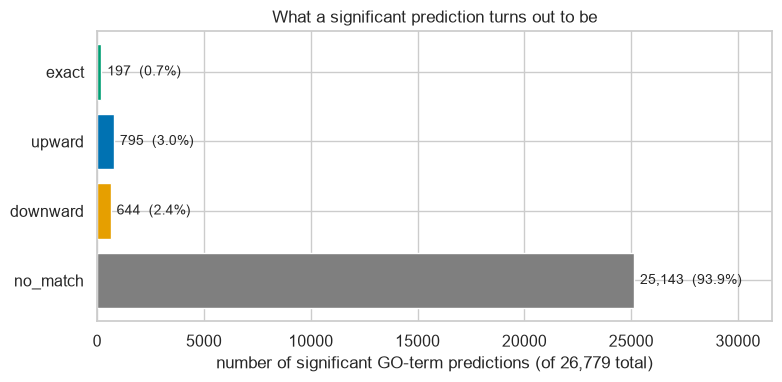

In [4]:
t = summary["terms"]
# field names in the summary JSON: n_exact, n_upward_total, n_downward_total, n_no_match
counts = pd.Series({"exact": t["n_exact"], "upward": t["n_upward_total"],
                    "downward": t["n_downward_total"], "no_match": t["n_no_match"]})[ORDER]
total_terms = counts.sum()
assert total_terms == t["n_total"]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(counts.index[::-1], counts.values[::-1], color=[COLORS[k] for k in ORDER[::-1]])
for bar, v in zip(bars, counts.values[::-1]):
    ax.text(bar.get_width() + total_terms * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{v:,}  ({v / total_terms:.1%})", va="center", fontsize=10)
ax.set_xlim(0, total_terms * 1.18)
ax.set_xlabel(f"number of significant GO-term predictions (of {total_terms:,} total)")
ax.set_title("What a significant prediction turns out to be")
fig.tight_layout()
save(fig, "02_outcome_breakdown")
plt.show()

## 3. Among the real matches, how close are they?

Even the matches that aren't exact come in different strengths: a 1-step relation (e.g. a direct parent
term) is a close, specific match; a 5+ step relation is a very loose, barely-informative one. Same blue
(upward) / orange (downward) as the previous plot, so the connection to the "upward"/"downward" slices
above is visually immediate.

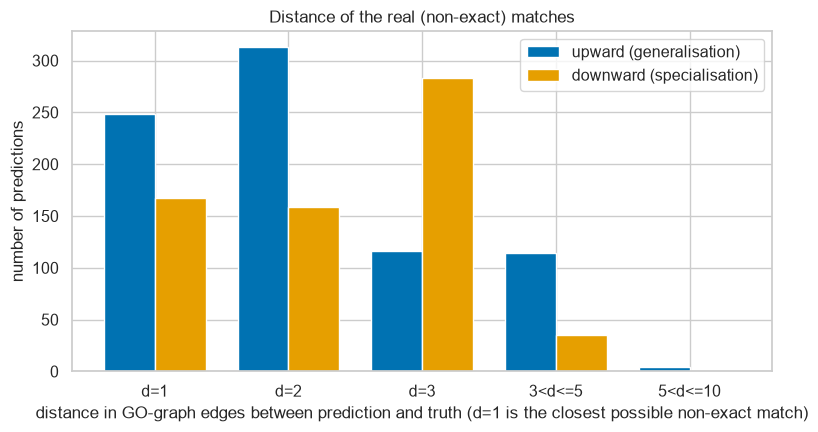

In [5]:
edges = summary["bin_edges"]  # upper bound of each non-exact distance bin, e.g. [1, 2, 3, 5, 10]
bin_labels = [f"d={edges[0]}"] + (
    [f"d={e}" if edges[i] - edges[i - 1] <= 1 else f"{edges[i-1]}<d<={e}" for i, e in enumerate(edges[1:], 1)]
)
up = summary["terms"]["upward_bins"]
down = summary["terms"]["downward_bins"]
dist = pd.DataFrame({"upward": [up.get(b, 0) for b in bin_labels],
                     "downward": [down.get(b, 0) for b in bin_labels]}, index=bin_labels)

fig, ax = plt.subplots(figsize=(8, 4.5))
x = range(len(dist))
w = 0.38
ax.bar([i - w / 2 for i in x], dist["upward"], width=w, color=COLORS["upward"], label="upward (generalisation)")
ax.bar([i + w / 2 for i in x], dist["downward"], width=w, color=COLORS["downward"], label="downward (specialisation)")
ax.set_xticks(list(x)); ax.set_xticklabels(dist.index)
ax.set_xlabel("distance in GO-graph edges between prediction and truth (d=1 is the closest possible non-exact match)")
ax.set_ylabel("number of predictions")
ax.set_title("Distance of the real (non-exact) matches")
ax.legend()
fig.tight_layout()
save(fig, "03_match_distance")
plt.show()

## 4. How many significant terms does a typical gene even get?

The 37% "zero significant terms" headline from the funnel is the extreme left bar of a much broader
distribution -- shown here in full so it isn't read as an isolated, cherry-picked statistic.

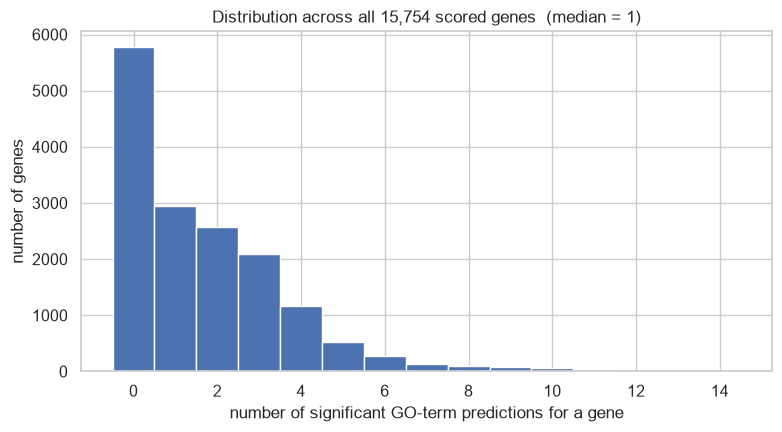

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
max_n = int(genes["n_significant"].max())
ax.hist(genes["n_significant"], bins=range(0, max_n + 2), align="left",
        color=COLORS["volume"], edgecolor="white")
ax.set_xlabel("number of significant GO-term predictions for a gene")
ax.set_ylabel("number of genes")
ax.set_title(f"Distribution across all {len(genes):,} scored genes  (median = {int(genes['n_significant'].median())})")
ax.set_xticks(range(0, max_n + 1, 2))
fig.tight_layout()
save(fig, "04_n_significant_distribution")
plt.show()

## 5. Is this a structural limitation, or arbitrary noise?

A separate, earlier analysis computed, for every gene, the **oracle ceiling**: the best possible score
*any* method could achieve using only this candidate vocabulary of GO terms (not what arm 1 achieved --
the theoretical best case). If genes that got a real match tend to have a *higher* ceiling than genes that
didn't, that confirms the result above is explained by a known, structural limit on what this vocabulary
can express for a given gene -- not by the method behaving arbitrarily.

genes with both a match result and a ceiling score: 15,754 / 15,754


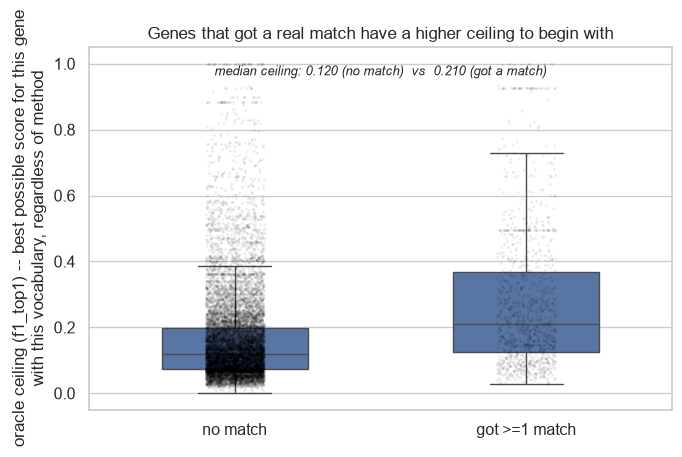

In [7]:
ceiling = pd.read_csv(ROOT / "data" / "go_ceiling_genes.tsv", sep="\t")
merged = genes.merge(ceiling, left_on="gene_id", right_on="ensembl_id", how="inner")
print(f"genes with both a match result and a ceiling score: {len(merged):,} / {len(genes):,}")

merged["got_a_match"] = ((merged["n_exact"] + merged["n_upward"] + merged["n_downward"]) > 0)
merged["group"] = merged["got_a_match"].map({True: "got >=1 match", False: "no match"})

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(data=merged, x="group", y="f1_top1", order=["no match", "got >=1 match"],
            color=COLORS["volume"], width=0.5, ax=ax, showfliers=False)
sns.stripplot(data=merged, x="group", y="f1_top1", order=["no match", "got >=1 match"],
             color="black", alpha=0.08, size=2, ax=ax)
ax.set_ylabel("oracle ceiling (f1_top1) -- best possible score for this gene\nwith this vocabulary, regardless of method")
ax.set_xlabel("")
ax.set_title("Genes that got a real match have a higher ceiling to begin with")
med_no = merged.loc[~merged["got_a_match"], "f1_top1"].median()
med_yes = merged.loc[merged["got_a_match"], "f1_top1"].median()
ax.text(0.5, 0.95, f"median ceiling: {med_no:.3f} (no match)  vs  {med_yes:.3f} (got a match)",
        transform=ax.transAxes, ha="center", va="top", fontsize=9, style="italic")
fig.tight_layout()
save(fig, "05_ceiling_vs_match")
plt.show()

## Part 1 summary

Each bullet gives what the plot shows and what it means for the project. Arm 1 is the no-LLM baseline that the
LLM arm (arm 2) has to be compared against, so "means for us" is mostly about how to read and use this baseline.
Data: 15,754 scoreable genes, 26,779 significant predictions.

- **Plot 1, funnel.** 63.3% of genes get at least one significant GO term, 7.7% (1,220) get at least one real
  match and 1.2% (188) an exact one; 36.7% get no output at all.
  *For us:* the baseline is weak: it is right for fewer than 1 in 12 genes. It also abstains on over a third of
  genes, while an LLM always answers. Comparing the arms on all genes mixes "wrong" with "silent", so we should
  report results both over all genes and over the genes where each method produced something.
- **Plot 2, outcome breakdown.** Of the 26,779 significant predictions, 93.9% are `no_match`, 3.0% upward, 2.4%
  downward, 0.7% exact.
  *For us:* "statistically significant" does not mean "correct" here. About 6.1% of significant terms are a
  match, against 3.5% expected from picking at random (Plot 16). That 6.1% is the number the LLM arm has to beat
  on the same scoring.
- **Plot 3, distance of the matches.** Among the 1,439 non-exact matches, upward matches are mostly close (56%
  within 2 GO edges) and downward ones a bit further out (most at 3 edges); none is more than 10 away.
  *For us:* our match rule (any ancestor or descendant counts) is not being carried by very loose relations, so we
  do not need a distance cut-off to keep it honest. A stricter variant (matches within 2 edges) is cheap to report
  alongside, and edges are coarse, so Plot 15 is the better view of how far off a match is.
- **Plot 4, significant terms per gene.** The median gene gets 1 significant term (mean 1.7, maximum 14).
  *For us:* the baseline's output is very short, so per-gene scores for it are noisy and top-k comparisons barely
  apply. Arm 2 can list up to 10 terms; a fair comparison should hold the number of predictions fixed (for
  example the top 3) or use a metric that accounts for list length, otherwise the longer list wins by volume.
- **Plot 5, ceiling against match.** Genes that got a match have a higher oracle ceiling (median 0.21) than genes
  that did not (0.12).
  *For us:* the cap on performance comes from the 52-term cell-level vocabulary and the evidence, not from the
  statistical method, so it applies to the LLM arm as well. Arm 2 should be judged against each gene's ceiling,
  not against a perfect score, and a low absolute score for either arm is partly a property of the setup.

Overall: arm 1 is a faithful reimplementation of g:Profiler's approach and 94% of its significant predictions do
not match the gene's known annotation. The hits it does make are biologically sound (GNAT1 to visual perception,
CSF1R to macrophage differentiation), so it is a correct but narrow baseline, not noise.

Part 2 below looks at which genes and terms account for the 7.7%, and whether that pattern is meaningful or an
artifact of something else.

# Part 2 — what characterizes a match?

Produced by `scripts/analyze_arm1_gene_properties.py`, which re-walks the same 15,754 runs and adds the
covariates needed here. Two new tables:

- **`arm1_gene_properties__all.json`** — one row per gene: expression breadth, how many GO terms the gene
  is independently annotated with (`n_direct_terms`), the oracle ceiling, a batch/tissue-homogeneity
  diagnostic, and its HGNC gene family.
- **`arm1_term_properties__all.json`** — one row per *significant* prediction (so ~26,779 rows, every
  outcome including `no_match`, not just the wins): its specificity (information content), the term's
  size (how many cell types carry it), its rank among that gene's significant predictions, and — for real
  matches only — the GOA evidence code(s) backing the specific true term it matched.

Two new colors are added to the same `COLORS` dict for the evidence-strength plot; every other plot below
reuses the exact-same `exact`/`upward`/`downward`/`no_match`/`volume` colors from Part 1.

In [8]:
COLORS["experimental"] = "#CC79A7"      # pink/magenta -- measured directly (e.g. IDA, IMP)
COLORS["non_experimental"] = "#999999"  # grey -- inferred (e.g. IBA, ISS, TAS) -- distinct from "no_match"
                                         # grey (#7F7F7F) so the two greys are not visually confused

gene_props = pd.DataFrame(json.loads((RESULTS_DIR / "arm1_gene_properties__all.json").read_text())["rows"])
term_props = pd.DataFrame(json.loads((RESULTS_DIR / "arm1_term_properties__all.json").read_text())["rows"])

# regression check: this richer, independently-recomputed extraction must reproduce Part 1's exact counts
recount = term_props["kind"].value_counts().to_dict()
expected = {"exact": t["n_exact"], "upward": t["n_upward_total"], "downward": t["n_downward_total"], "no_match": t["n_no_match"]}
assert recount == expected, f"Part 2 term counts do not match Part 1: {recount} vs {expected}"

gene_props["got_a_match"] = (gene_props[["n_exact", "n_upward", "n_downward"]].sum(axis=1) > 0)
print(f"genes in Part 2 table: {len(gene_props):,}   significant terms: {len(term_props):,}")
print("cross-check vs Part 1: OK")

genes in Part 2 table: 15,754   significant terms: 26,779
cross-check vs Part 1: OK


## 6. Does expression breadth predict getting a match?

"Breadth" = the fraction of the gene's cell types where it is reliably expressed. A gene expressed
narrowly has a much smaller query against the background, which (see `approaches/README.md`'s derivation
of the query/background ceiling) mechanically allows a higher maximum possible enrichment -- so narrower
genes are expected to do better, for a structural reason that has nothing to do with biology quality.

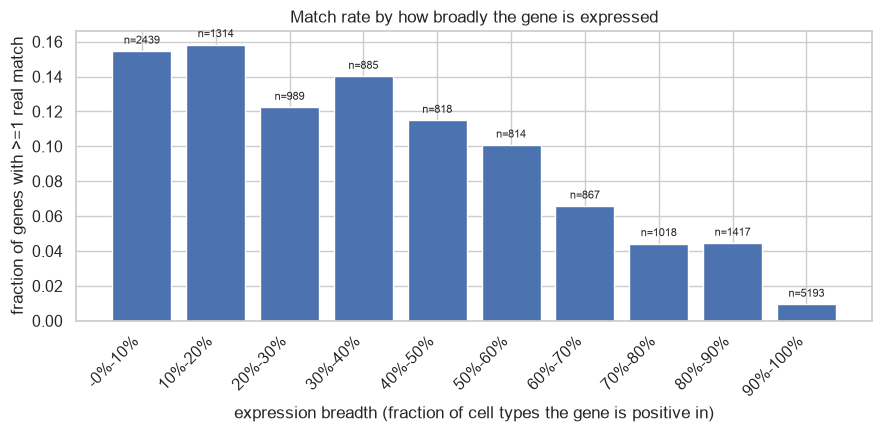

In [9]:
gene_props["breadth_bin"] = pd.cut(gene_props["breadth"], bins=[i / 10 for i in range(11)], include_lowest=True)
rate_by_breadth = gene_props.groupby("breadth_bin", observed=True)["got_a_match"].agg(["mean", "count"])

fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar(range(len(rate_by_breadth)), rate_by_breadth["mean"], color=COLORS["volume"])
for i, (bar, n) in enumerate(zip(bars, rate_by_breadth["count"])):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003, f"n={n}",
            ha="center", va="bottom", fontsize=8)
ax.set_xticks(range(len(rate_by_breadth)))
ax.set_xticklabels([f"{iv.left:.0%}-{iv.right:.0%}" for iv in rate_by_breadth.index], rotation=45, ha="right")
ax.set_xlabel("expression breadth (fraction of cell types the gene is positive in)")
ax.set_ylabel("fraction of genes with >=1 real match")
ax.set_title("Match rate by how broadly the gene is expressed")
fig.tight_layout()
save(fig, "06_breadth_vs_match")
plt.show()

## 7. How specific are the predicted terms, by outcome?

**Information content (IC)** measures how rare/specific a GO term is among annotated human genes --
`IC = -ln(fraction of genes carrying it)`. A generic term like "biological_process" has IC ~0; a narrow,
specific term has a high IC. If `exact` matches cluster at LOW IC, the method's wins are cheap, generic
hits; if they cluster at HIGH IC, they are genuinely specific, informative predictions.

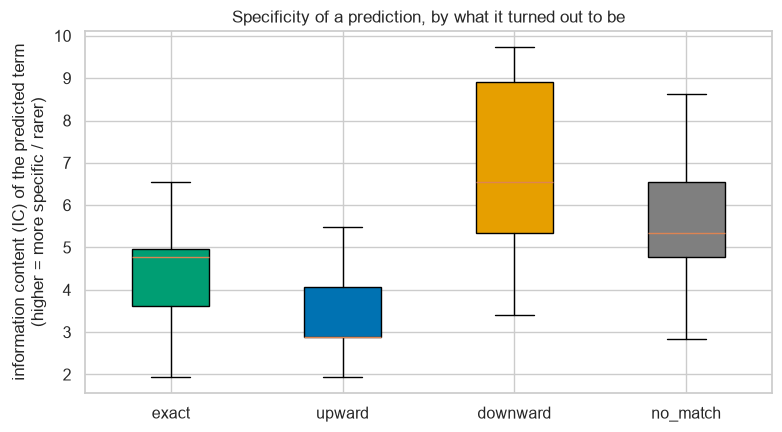

In [10]:
fig, ax = plt.subplots(figsize=(8, 4.5))
data = [term_props.loc[term_props["kind"] == k, "ic"] for k in ORDER]
bp = ax.boxplot(data, tick_labels=ORDER, patch_artist=True, showfliers=False)
for patch, k in zip(bp["boxes"], ORDER):
    patch.set_facecolor(COLORS[k])
ax.set_ylabel("information content (IC) of the predicted term\n(higher = more specific / rarer)")
ax.set_title("Specificity of a prediction, by what it turned out to be")
fig.tight_layout()
save(fig, "07_ic_by_outcome")
plt.show()

## 8. Is match rate just tracking how much a gene is annotated?

A gene with 40 known true terms has far more "targets" to accidentally land a match on than one with 3,
independent of whether arm 1 is finding anything real. **Left**: raw match rate vs. annotation richness --
expected to rise simply from having more targets. **Right**: match rate *normalized per true term
available* (`n_matches / n_direct_terms`) -- if this is flat or declining, the raw rise on the left is
explained by opportunity alone, not a genuinely better hit rate for well-annotated genes. This also speaks
to this project's earlier §L5 finding that annotation richness tracks how well-studied a gene is, not its
biological importance.

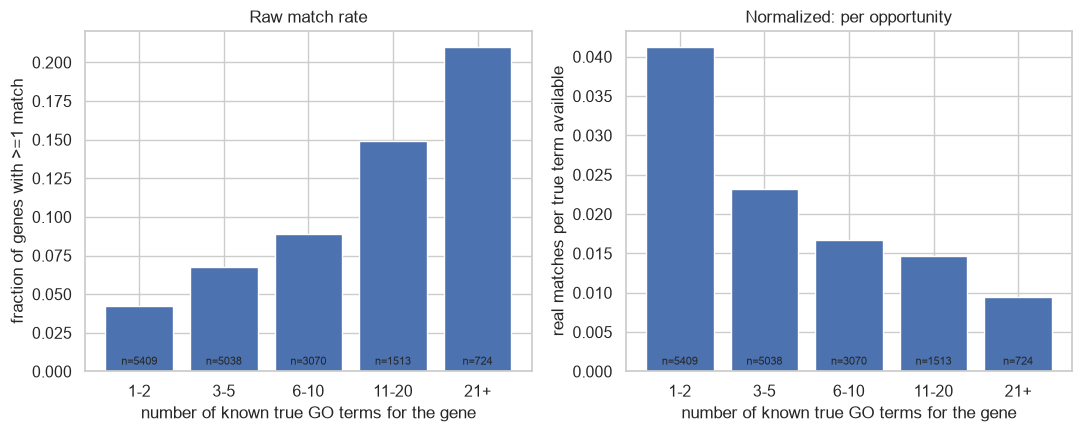

In [11]:
bins = [0, 3, 6, 11, 21, gene_props["n_direct_terms"].max() + 1]
labels = ["1-2", "3-5", "6-10", "11-20", "21+"]
gene_props["richness_bin"] = pd.cut(gene_props["n_direct_terms"], bins=bins, labels=labels, right=False)
gene_props["n_real_matches"] = gene_props[["n_exact", "n_upward", "n_downward"]].sum(axis=1)
gene_props["matches_per_true_term"] = gene_props["n_real_matches"] / gene_props["n_direct_terms"]

by_rich = gene_props.groupby("richness_bin", observed=True).agg(
    match_rate=("got_a_match", "mean"), per_term=("matches_per_true_term", "mean"), n=("gene_id", "count"))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.bar(by_rich.index.astype(str), by_rich["match_rate"], color=COLORS["volume"])
ax1.set_xlabel("number of known true GO terms for the gene"); ax1.set_ylabel("fraction of genes with >=1 match")
ax1.set_title("Raw match rate")
ax2.bar(by_rich.index.astype(str), by_rich["per_term"], color=COLORS["volume"])
ax2.set_xlabel("number of known true GO terms for the gene"); ax2.set_ylabel("real matches per true term available")
ax2.set_title("Normalized: per opportunity")
for ax in (ax1, ax2):
    for i, n in enumerate(by_rich["n"]):
        ax.text(i, ax.get_ylim()[1] * 0.02, f"n={n}", ha="center", fontsize=8)
fig.tight_layout()
save(fig, "08_annotation_richness")
plt.show()

## 9. Term size (statistical power) by outcome

`term_size` (K) is how many cell types in the background carry a candidate term -- a small K means a
single hit or miss can swing significance (see the arm-1 README's `--min-term-size` discussion). If real
matches cluster on small-K terms, the "win" may be a low-power coincidence rather than a robust signal.

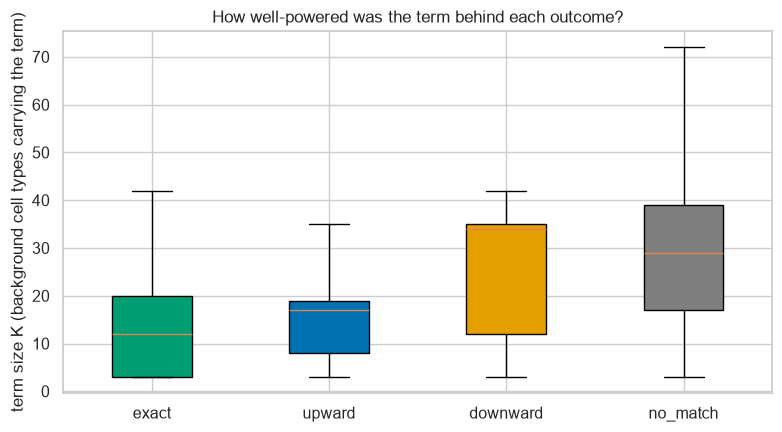

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.5))
data = [term_props.loc[term_props["kind"] == k, "term_size"] for k in ORDER]
bp = ax.boxplot(data, tick_labels=ORDER, patch_artist=True, showfliers=False)
for patch, k in zip(bp["boxes"], ORDER):
    patch.set_facecolor(COLORS[k])
ax.set_ylabel("term size K (background cell types carrying the term)")
ax.set_title("How well-powered was the term behind each outcome?")
fig.tight_layout()
save(fig, "09_term_size_by_outcome")
plt.show()

## 10. Calibration — does arm 1's own ranking mean anything?

Among a gene's significant predictions, the one with the smallest p-value (g:SCS) is ranked first. If that
top-ranked term is no more likely to be a real match than the 3rd or 4th one, arm 1's significance ordering
carries no information about which of its own predictions to trust -- a distinct finding from "does it find
anything at all".

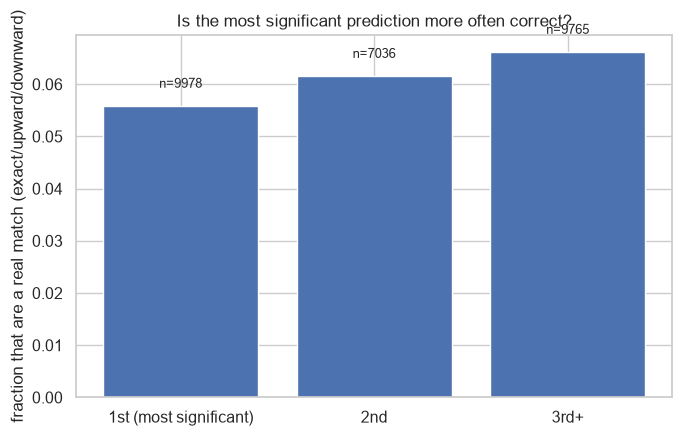

In [13]:
term_props["rank_bucket"] = term_props["rank"].clip(upper=3).map({1: "1st (most significant)", 2: "2nd", 3: "3rd+"})
term_props["is_real_match"] = term_props["kind"] != "no_match"
by_rank = term_props.groupby("rank_bucket", observed=True)["is_real_match"].agg(["mean", "count"])
by_rank = by_rank.reindex(["1st (most significant)", "2nd", "3rd+"])

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(by_rank.index, by_rank["mean"], color=COLORS["volume"])
for bar, n in zip(bars, by_rank["count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003, f"n={n}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("fraction that are a real match (exact/upward/downward)")
ax.set_title("Is the most significant prediction more often correct?")
fig.tight_layout()
save(fig, "10_calibration_by_rank")
plt.show()

## 11. Which vocabulary terms account for the matches?

A Pareto view of the 52-term candidate vocabulary: if a handful of terms account for most matches, the
method's apparent success is concentrated in a few well-annotated biological domains rather than spread
across general biology.

/var/folders/6n/xwm6w0015417z1bwqghfk2_c0000gn/T/ipykernel_90694/2153285786.py:13: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


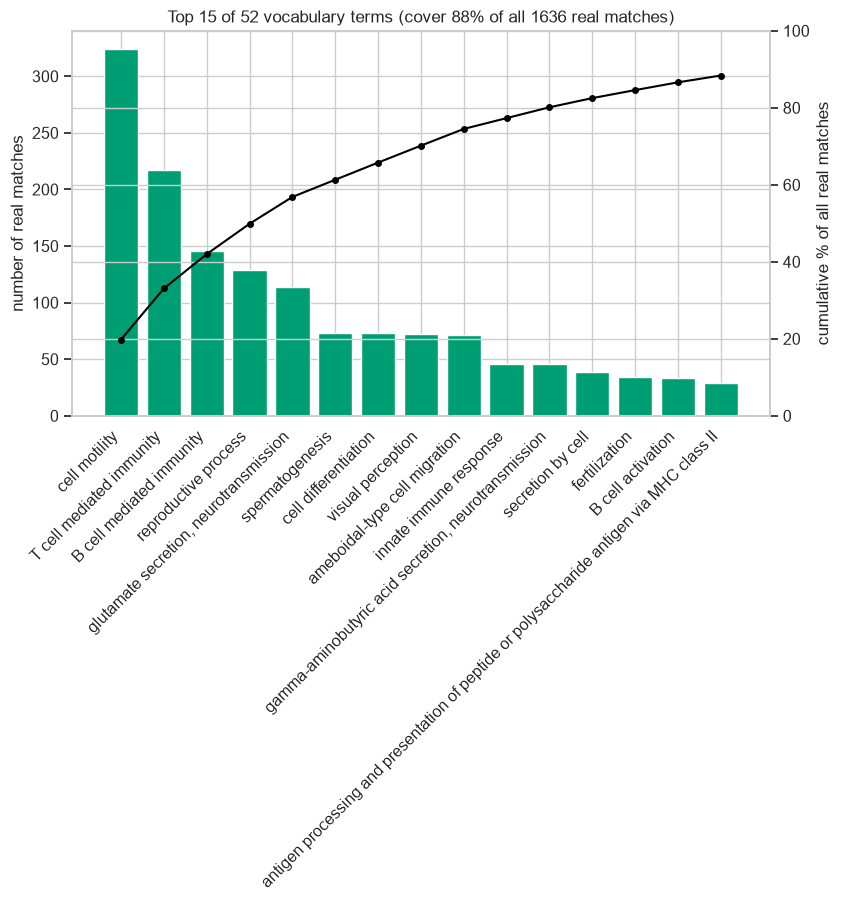

In [14]:
wins = term_props[term_props["kind"] != "no_match"]
top = wins["label"].value_counts().head(15)
cum_pct = (top.cumsum() / len(wins) * 100)

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(range(len(top)), top.values, color=COLORS["exact"])
ax1.set_xticks(range(len(top))); ax1.set_xticklabels(top.index, rotation=45, ha="right")
ax1.set_ylabel("number of real matches"); ax1.set_xlabel("")
ax2 = ax1.twinx()
ax2.plot(range(len(top)), cum_pct.values, color="black", marker="o", markersize=4)
ax2.set_ylabel("cumulative % of all real matches"); ax2.set_ylim(0, 100)
ax1.set_title(f"Top 15 of 52 vocabulary terms (cover {cum_pct.iloc[-1]:.0f}% of all {len(wins)} real matches)")
fig.tight_layout()
save(fig, "11_pareto_terms")
plt.show()

## 12. Batch/tissue artifact: matched vs. unmatched genes

`frac_allornothing_tissues` is a pre-existing diagnostic (`core/enrichment.tissue_homogeneity`): the share
of a gene's tissues where it is almost entirely positive or almost entirely negative -- usually a sign of
which study profiled that tissue and how deeply, not gene biology (see `approaches/README.md`, §L9/§L11).
If matched genes score similarly to unmatched ones here, the matches are not simply riding a batch
artifact.

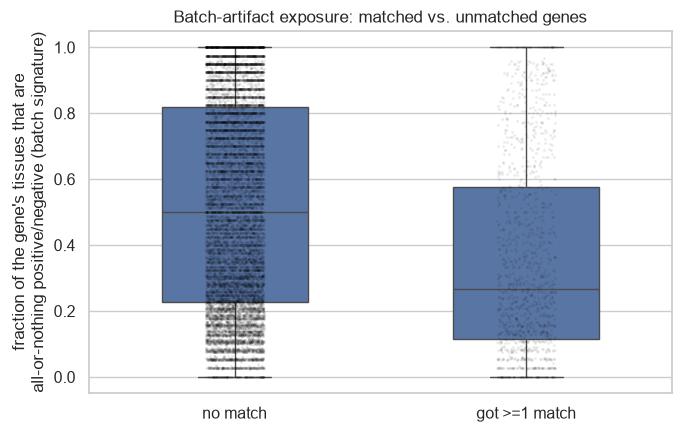

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
plot_df = gene_props.assign(group=gene_props["got_a_match"].map({True: "got >=1 match", False: "no match"}))
sns.boxplot(data=plot_df, x="group", y="frac_allornothing_tissues", order=["no match", "got >=1 match"],
            color=COLORS["volume"], width=0.5, ax=ax, showfliers=False)
sns.stripplot(data=plot_df, x="group", y="frac_allornothing_tissues", order=["no match", "got >=1 match"],
             color="black", alpha=0.08, size=2, ax=ax)
ax.set_ylabel("fraction of the gene's tissues that are\nall-or-nothing positive/negative (batch signature)")
ax.set_xlabel("")
ax.set_title("Batch-artifact exposure: matched vs. unmatched genes")
fig.tight_layout()
save(fig, "12_batch_artifact")
plt.show()

## 13. Are the matches concentrated in a few gene families?

HGNC groups genes into families (e.g. "Opsins", "Immunoglobulin like domain containing"). If matched genes
cluster heavily into a handful of families, the method's apparent reach is narrower than "7.7% of genes"
suggests -- it may really be "most members of a few families this vocabulary already encodes well".

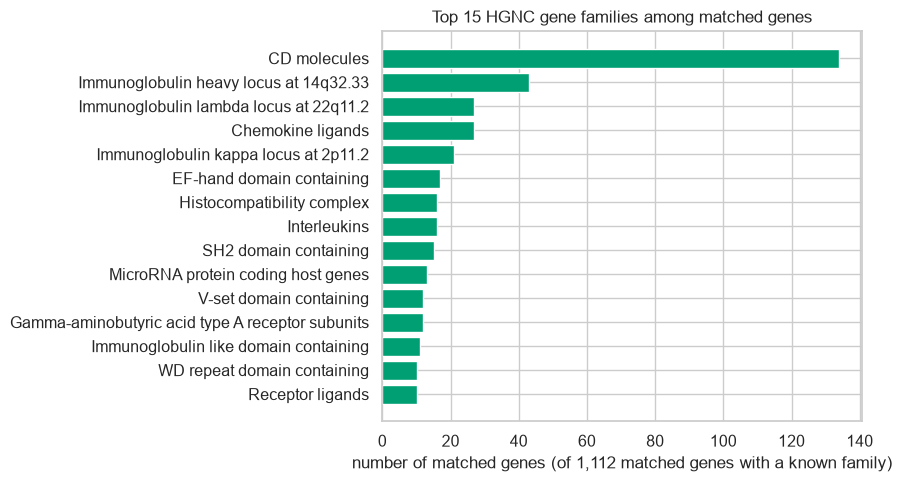

top 5 families account for 22.7% of all matched genes with a known family


In [16]:
matched = gene_props[gene_props["got_a_match"] & gene_props["gene_group"].notna()]
top_fam = matched["gene_group"].value_counts().head(15)
background_rate = gene_props[gene_props["gene_group"].notna()]["gene_group"].value_counts(normalize=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top_fam.index[::-1], top_fam.values[::-1], color=COLORS["exact"])
ax.set_xlabel(f"number of matched genes (of {len(matched):,} matched genes with a known family)")
ax.set_title("Top 15 HGNC gene families among matched genes")
fig.tight_layout()
save(fig, "13_gene_families")
plt.show()

print(f"top 5 families account for {top_fam.head(5).sum() / len(matched):.1%} of all matched genes with a known family")

## 14. How strong is the evidence behind the matched truth term?

For every real match, the gene's own true term it matched against has GOA evidence code(s) --
**experimental** (directly measured: IDA, IMP, IGI, IEP, ...) or **non-experimental** (inferred: IBA
phylogeny, ISS sequence similarity, TAS/NAS author statement, ...). A match resting on experimental
evidence is a more trustworthy "win" than one resting only on an inferred annotation.

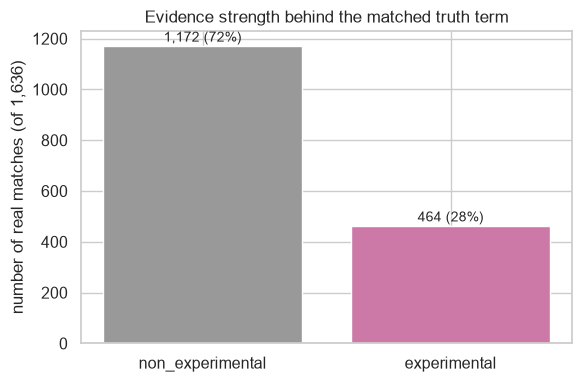

In [17]:
ev = wins.dropna(subset=["matched_evidence_experimental"])
counts = ev["matched_evidence_experimental"].map({True: "experimental", False: "non_experimental"}).value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(counts.index, counts.values, color=[COLORS[k] for k in counts.index])
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + len(ev) * 0.01,
            f"{v:,} ({v/len(ev):.0%})", ha="center", fontsize=10)
ax.set_ylabel(f"number of real matches (of {len(ev):,})")
ax.set_title("Evidence strength behind the matched truth term")
fig.tight_layout()
save(fig, "14_evidence_strength")
plt.show()

## 15. Among the real matches, how far off are they in specificity (not just graph steps)?

Plot 3 showed how far a match is in GO-graph EDGES. That treats every edge as equal, but the graph is
uneven -- one edge can separate two near-synonyms, or a very general term from a very specific one. This
plot asks the same "how close?" question in information content (IC) instead: IC = -ln(fraction of genes
carrying the term), so a MORE SPECIFIC/rarer term has a HIGHER IC.

For every real match, this is `IC_true - IC_predicted` (signed):
- **upward** matches are necessarily positive -- the model predicted an ancestor of the true term, and an
  ancestor can never be more specific than its descendant, so the true term's IC is always >= the
  prediction's. The size of the gap is what matters: a small positive gap is a near-miss (predicted the
  true term's immediate parent); a large one means the model landed on something much more generic than
  the real answer.
- **downward** matches are necessarily negative, for the mirrored reason -- the model over-specialised.
- **exact** matches are left out: their gap is 0 by construction (the true term IS the predicted term), so
  there is no spread to show.

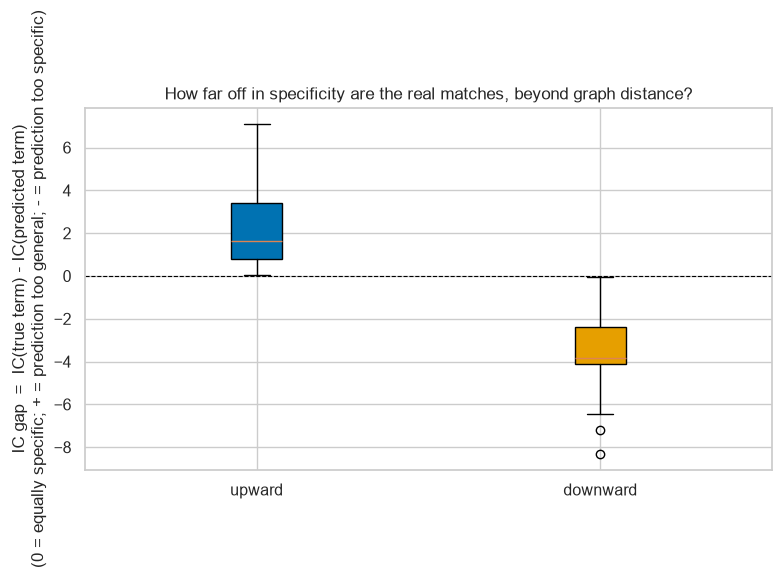

In [18]:
# ic_gap is only defined for real matches (exact/upward/downward), not no_match -- see
# scripts/analyze_arm1_gene_properties.py. `wins` already excludes no_match.
gap_order = [k for k in ORDER if k not in ("exact", "no_match")]
data = [wins.loc[wins["kind"] == k, "ic_gap"] for k in gap_order]

fig, ax = plt.subplots(figsize=(8, 4.5))
bp = ax.boxplot(data, tick_labels=gap_order, patch_artist=True, showfliers=True)
for patch, k in zip(bp["boxes"], gap_order):
    patch.set_facecolor(COLORS[k])
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_ylabel("IC gap  =  IC(true term) - IC(predicted term)\n(0 = equally specific; + = prediction too general; - = prediction too specific)")
ax.set_title("How far off in specificity are the real matches, beyond graph distance?")
fig.tight_layout()
save(fig, "15_ic_gap_by_outcome")
plt.show()

## 16. Would a random guess have matched just as often? (chance baseline)

Concern: a `downward` match only needs the prediction to be ANY descendant of one of the gene's true terms.
If a gene's true terms are very general (low IC, e.g. "cell differentiation"), many of the 52 candidate
terms are descendants of them, so almost any guess would match. This plot checks that directly.

**Chance baseline**: for each gene, the fraction of the 52 candidate terms that would count as a match
(exact / upward / downward) given that gene's true terms. A gene that produced `n` significant predictions
would, by picking `n` of the 52 at random, be expected to get `n x (that fraction)` matches. Summed over
genes, this is the number of matches random picking would give.

- **Left**: observed matches vs. the random-pick expectation, per match kind. Observed above expected means
  the method does better than chance; observed close to expected means that kind of match is largely
  explained by easy targets.
- **Right**: the same comparison as a match rate, by how general the gene's true terms are (quintiles of the
  mean IC of the gene's direct true terms; leftmost = most general).

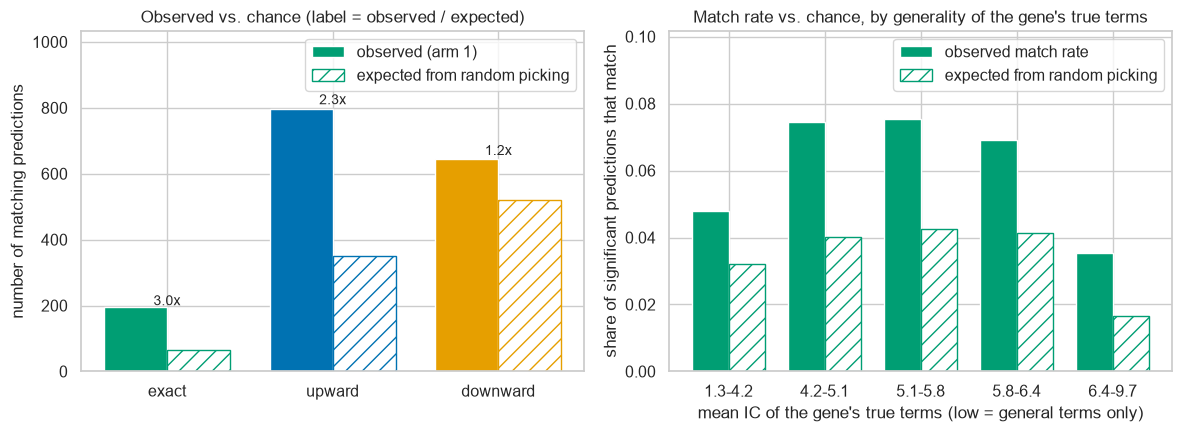

In [19]:
chance = pd.DataFrame(json.loads((RESULTS_DIR / "arm1_chance_baseline__all.json").read_text()))
w = chance[chance["n_significant"] > 0].copy()

kinds = ["exact", "upward", "downward"]
obs = [w[f"n_{k}"].sum() for k in kinds]
exp = [(w["n_significant"] * w[f"chance_{k}"]).sum() for k in kinds]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
x = range(len(kinds)); bw = 0.38
ax1.bar([i - bw / 2 for i in x], obs, width=bw, color=[COLORS[k] for k in kinds], label="observed (arm 1)")
ax1.bar([i + bw / 2 for i in x], exp, width=bw, color="white", edgecolor=[COLORS[k] for k in kinds],
        hatch="//", label="expected from random picking")
for i, (o, e) in enumerate(zip(obs, exp)):
    ax1.text(i, max(o, e) * 1.02, f"{o / e:.1f}x", ha="center", fontsize=10)
ax1.set_xticks(list(x)); ax1.set_xticklabels(kinds)
ax1.set_ylabel("number of matching predictions")
ax1.set_title("Observed vs. chance (label = observed / expected)")
ax1.set_ylim(0, max(obs + exp) * 1.3)
ax1.legend(loc="upper right")

w["ic_bin"] = pd.qcut(w["mean_true_ic"], 5)
g = w.groupby("ic_bin", observed=True)
obs_rate = g.apply(lambda d: (d[["n_exact", "n_upward", "n_downward"]].sum().sum()) / d["n_significant"].sum(), include_groups=False)
exp_rate = g.apply(lambda d: (d["n_significant"] * d["chance"]).sum() / d["n_significant"].sum(), include_groups=False)
labels = [f"{iv.left:.1f}-{iv.right:.1f}" for iv in obs_rate.index]
xx = range(len(labels))
ax2.bar([i - bw / 2 for i in xx], obs_rate.values, width=bw, color=COLORS["exact"], label="observed match rate")
ax2.bar([i + bw / 2 for i in xx], exp_rate.values, width=bw, color="white", edgecolor=COLORS["exact"],
        hatch="//", label="expected from random picking")
ax2.set_xticks(list(xx)); ax2.set_xticklabels(labels)
ax2.set_xlabel("mean IC of the gene's true terms (low = general terms only)")
ax2.set_ylabel("share of significant predictions that match")
ax2.set_title("Match rate vs. chance, by generality of the gene's true terms")
ax2.set_ylim(0, obs_rate.max() * 1.35)
ax2.legend(loc="upper right")
fig.tight_layout()
save(fig, "16_chance_baseline")
plt.show()

## Part 2 summary

Each bullet gives what the plot shows and what it means for the project.

- **Plot 6, expression breadth.** Match rate falls from about 15% for genes expressed in under 20% of cell types
  to under 1% above 90%, roughly 17x.
  *For us:* arm 1 only works for narrowly expressed genes, and the median gene is expressed in 67% of cell types,
  so it fails on most of the dataset. The useful question for the LLM arm is whether it adds anything on broad
  genes, where the baseline has nothing. Results for both arms should be split by breadth, not pooled.
- **Plot 7, specificity of predictions (IC).** Exact matches have moderate-to-high specificity (median IC about
  4.8); `no_match` terms are about as specific (about 5.3).
  *For us:* the baseline's few wins are not generic terms, so it is not trivially winning. Specificity of a
  prediction does not by itself tell right from wrong, so it is not a useful filter either.
- **Plot 8, annotation richness.** The raw match rate rises from 4% to 21% with more known true terms, but the
  rate per available true term falls from 0.041 to 0.009.
  *For us:* well-studied genes do get more matches in raw counts, but not because each of their terms is easier,
  so annotation bias is not what drives the result. Raw match counts still depend on how many true terms a gene
  has, so scores should be normalized (for example against the ceiling) before comparing genes or arms.
- **Plot 9, term size (K).** Exact matches use smaller terms (median K about 12) than `no_match` terms (about 29).
  *For us:* the baseline does not win by picking large, easy, high-power terms. This keeps the baseline from
  being dismissed as a size artifact, which makes it a harder baseline to beat.
- **Plot 10, calibration by rank.** The most significant prediction is correct 5.6% of the time, the third or
  later one 6.6%.
  *For us:* arm 1's ordering carries no information, so rank-based scores for arm 1 are no better than set-based
  ones and its significance order cannot be used as a confidence. A confidence that actually separates right from
  wrong would be a real advantage for arm 2, so its confidence values should be tested the same way.
- **Plot 11, which vocabulary terms win.** 15 of the 52 candidate terms account for 88% of the real matches.
  *For us:* the baseline's success rests on a small part of the vocabulary, so a headline match rate hides how
  narrow it is. Per-term results should be reported next to the overall rate.
- **Plot 12, batch/tissue artifact.** Matched genes have lower batch-signature exposure (median 0.27) than
  unmatched ones (0.50).
  *For us:* the matches are not a study or batch artifact, so they can be trusted as expression signal. It also
  means batch effects do not explain the low match rate overall.
- **Plot 13, gene families.** "CD molecules" outweighs any other family among matched genes, and immune families
  dominate the rest.
  *For us:* the 7.7% is close to "a few well-annotated immune families". If we only report an overall rate, a
  method that is good at immune genes looks good everywhere. Both arms should be evaluated with and without
  immune families to see whether anything generalizes.
- **Plot 14, evidence strength.** 72% of the matched true terms rest only on non-experimental evidence (inferred
  from sequence, phylogeny or author statements); 28% on direct experiments.
  *For us:* our ground truth is itself partly computational, so some "correct" answers are inferences about similar
  genes. A sensitivity check that scores against experimental evidence only would show how much of any result
  depends on that.
- **Plot 15, specificity gap of the matches.** For non-exact matches, IC(true) minus IC(predicted). Upward matches
  are too general by a median of 1.66 IC units (about 5x rarer true term), downward matches too specific by 3.82
  (about 46x). Exact matches are left out (gap 0 by definition).
  *For us:* a match is usually right in direction but at the wrong level of detail, and downward matches miss by
  much more because the 52 candidates are narrow while many true terms are general. A yes/no match overstates
  quality, so the IC-weighted score already in `core/go_scoring.py` should stay the primary measure, and the
  prompt for arm 2 should address granularity.
- **Plot 16, chance baseline.** Random picking among the 52 candidates would give 934 matches against the 1,636
  observed (1.75x): exact 3.0x, upward 2.3x, downward 1.2x (644 vs 520).
  *For us:* about 80% of downward matches are easy targets and should not be counted as wins, or at least be
  reported separately. Only exact and upward matches are clearly above chance. The same chance baseline should be
  computed for arm 2 so that both arms are compared against the same reference.

**Taken together:** arm 1 is a narrow baseline: it works for narrowly expressed genes in a few immune families,
its exact and upward hits are above chance, and its downward hits mostly are not. For arm 2 this means three
things: stratify by breadth and gene family, count matches against the chance baseline, and judge confidence and
granularity, not just the match rate.

# Part 3 — the terms themselves: which GO terms does arm 1 assign, and why those?

Parts 1–2 asked which *genes* work. Part 3 flips the unit: the 52 candidate GO terms (every term arm 1 may
assign). A few of them are assigned thousands of times, so the questions here are: how often does each term
occur among the cell types that define it, is it assigned more or less often than that predicts, how often is it
actually right, and are some terms close to duplicates of each other?

**One caution on a number from earlier discussion.** `term_size` stored per run is the number of cell types
carrying the term *inside that gene's called universe*, so it changes from gene to gene. Everything below that
says "how often the term occurs among the cell types" instead uses the fixed, gene-independent count of annotated
cell types carrying the term (`K_ct`, taken from the term-to-cell-type incidence matrix). Any figure quoted
earlier from per-run `term_size` should be disregarded in favour of the values printed here.

In [20]:
import numpy as np

prof = json.loads((RESULTS_DIR / "arm1_term_profile__all.json").read_text())
pairs = json.loads((RESULTS_DIR / "arm1_term_pairs__all.json").read_text())
ps = prof["summary"]
tp3 = pd.DataFrame(prof["rows"])
assert tp3["assigned"].sum() == len(term_props), "term-level assignment total does not match Part 2's table"

# Terms shown in the labelled plots: assigned to at least this many genes (stated on every such plot).
MIN_ASSIGNED = 100
big = tp3[tp3["assigned"] >= MIN_ASSIGNED].sort_values("assigned", ascending=False).reset_index(drop=True)
short = lambda s, n=44: s if len(s) <= n else s[: n - 1] + "…"

print(f"candidate terms: {len(tp3)}   annotated cell types: {ps['n_annotated_cell_types']}   "
      f"annotated CL|UBERON rows: {ps['n_annotated_rows']}")
print(f"terms never assigned: {(tp3['assigned'] == 0).sum()}   terms assigned >= {MIN_ASSIGNED} times (shown below): {len(big)}")
print(f"Spearman(times assigned, fixed carrier-cell-type count):  all 52 terms {ps['spearman_assigned_vs_K_ct_all_terms']:.2f}, "
      f"assigned terms only {ps['spearman_assigned_vs_K_ct_assigned_terms']:.2f}")
print(f"Spearman(precision, carrier-cell-type count), terms with >= {MIN_ASSIGNED} assignments:  "
      f"{ps['spearman_precision_vs_K_ct_terms_assigned_ge_100']:.2f}")

candidate terms: 52   annotated cell types: 358   annotated CL|UBERON rows: 1469
terms never assigned: 3   terms assigned >= 100 times (shown below): 30
Spearman(times assigned, fixed carrier-cell-type count):  all 52 terms 0.80, assigned terms only 0.76
Spearman(precision, carrier-cell-type count), terms with >= 100 assignments:  -0.32


## 17. Is a term assigned often simply because many cell types carry it?

- **Left**: each dot is one candidate term. x = the share of annotated cell types that carry the term
  (`K_ct / number of annotated cell types`), y = in how many genes arm 1 assigned it. Linear axes on purpose:
  a log scale would flatten exactly the spread this plot needs to show. The three terms never assigned sit on the
  x axis.
- **Right**: the most-assigned terms with the share of cell types carrying each, so the two quantities can be
  read off side by side.

Spearman's ρ is a rank correlation (1 = the term with more carrier cell types is always the one assigned more).

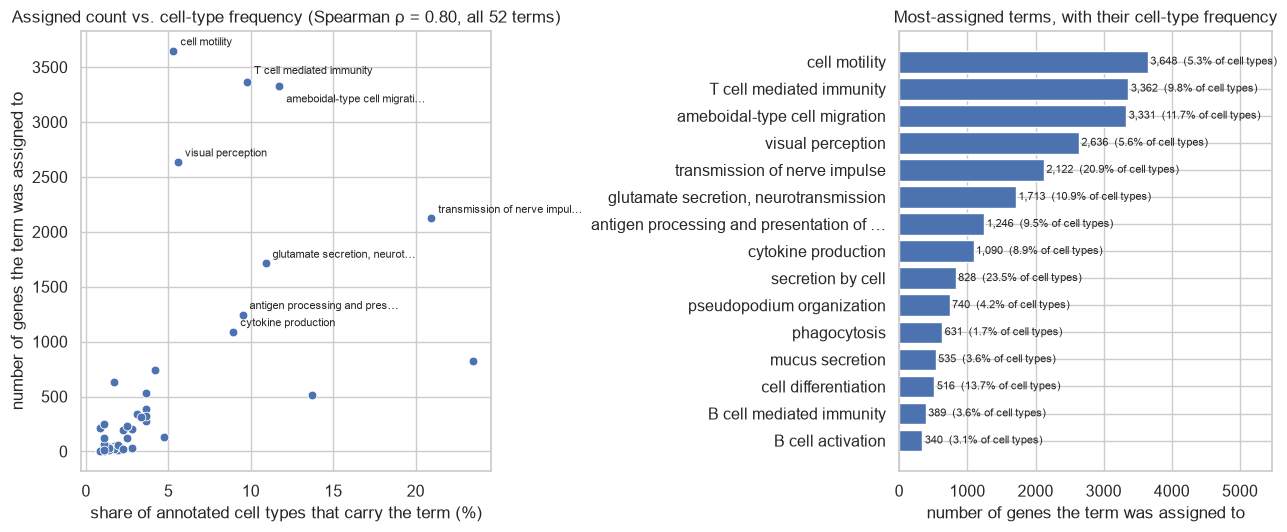

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5), gridspec_kw={"width_ratios": [1.1, 1]})
x = tp3["frac_ct"] * 100
ax1.scatter(x, tp3["assigned"], s=40, color=COLORS["volume"], edgecolor="white", linewidth=0.6, zorder=3)
offsets = [(5, 4), (5, 6), (5, -12), (5, 4), (5, 4), (5, 4), (5, 4), (5, 4)]  # T cell / ameboidal dots sit close together
for (_, r), off in zip(tp3.nlargest(8, "assigned").iterrows(), offsets):
    ax1.annotate(short(r["label"], 28), (r["frac_ct"] * 100, r["assigned"]), xytext=off, textcoords="offset points", fontsize=8)
ax1.set_xlabel("share of annotated cell types that carry the term (%)")
ax1.set_ylabel("number of genes the term was assigned to")
ax1.set_title(f"Assigned count vs. cell-type frequency (Spearman ρ = {ps['spearman_assigned_vs_K_ct_all_terms']:.2f}, all 52 terms)")

top = big.head(15)[::-1]
bars = ax2.barh([short(l, 40) for l in top["label"]], top["assigned"], color=COLORS["volume"])
for bar, (_, r) in zip(bars, top.iterrows()):
    ax2.text(bar.get_width() + big["assigned"].max() * 0.01, bar.get_y() + bar.get_height() / 2,
             f"{r['assigned']:,}  ({r['frac_ct']*100:.1f}% of cell types)", va="center", fontsize=8)
ax2.set_xlim(0, big["assigned"].max() * 1.5)
ax2.set_xlabel("number of genes the term was assigned to")
ax2.set_title("Most-assigned terms, with their cell-type frequency")
fig.tight_layout()
save(fig, "17_assigned_vs_celltype_frequency")
plt.show()

## 18. When a term is assigned, how often is it right — compared with how often it *would* be right by chance?

For each frequently assigned term (≥ 100 genes): the bar is its **precision**, the share of its assignments that
are a real match, split by match kind with the same colours as Part 1. The black diamond is the term's **base
rate**: the share of *all* genes for which this term would count as a match (exact, upward or downward) if it were
assigned. Precision to the right of the diamond means the term is right more often than assigning it blindly
would be; to the left means worse than blind. Terms that are descendants of very general true terms have high base
rates, which is the easy-target effect from Plot 16, now per term.

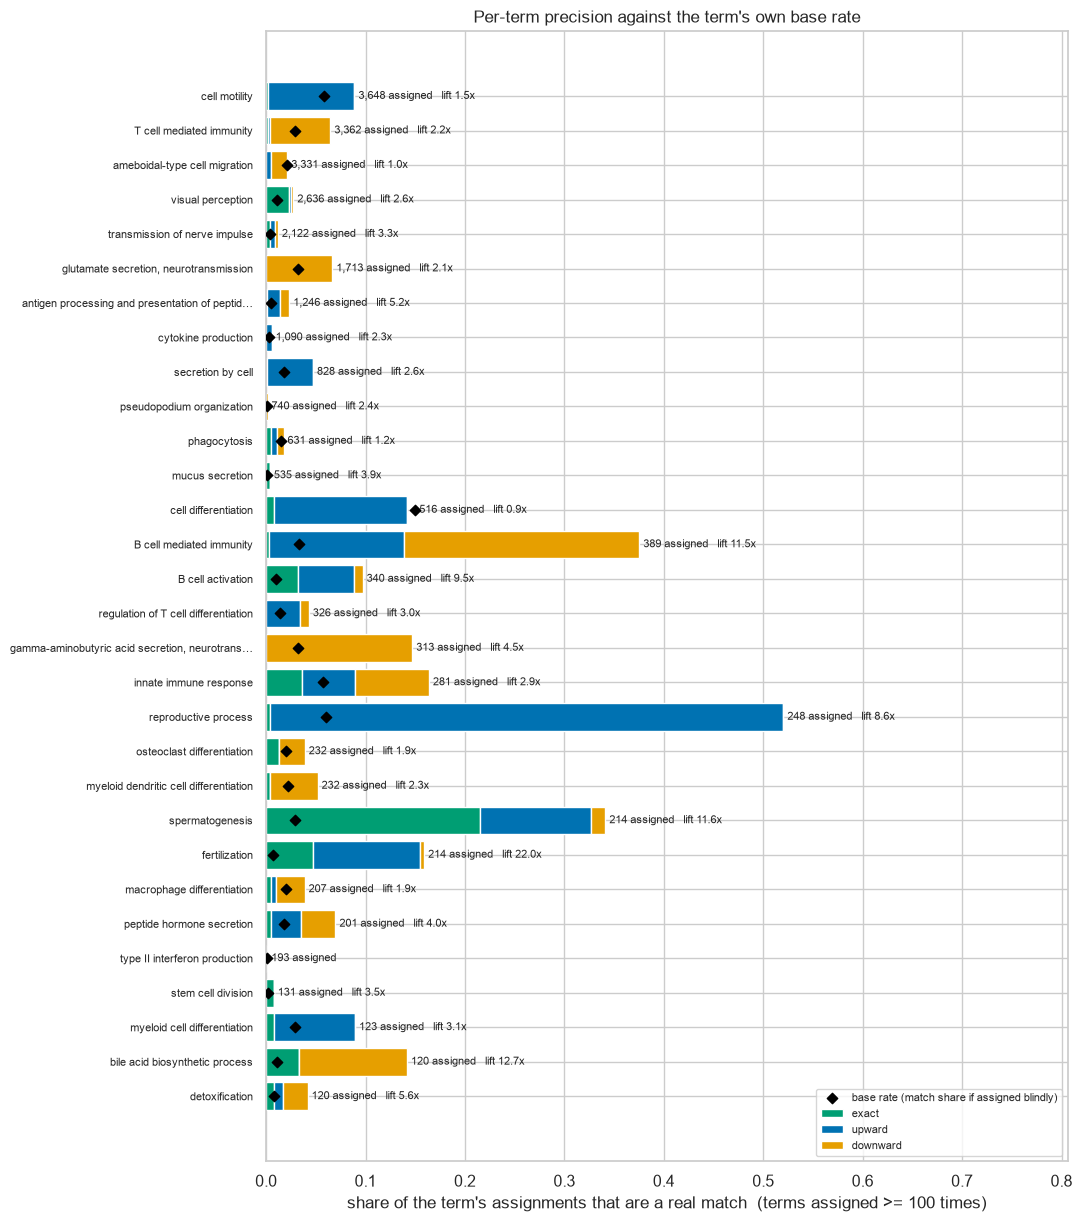

In [22]:
d = big[::-1].reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 0.34 * len(d) + 2.2))
left = np.zeros(len(d))
for k in ["exact", "upward", "downward"]:
    vals = (d[f"n_{k}"] / d["assigned"]).to_numpy()
    ax.barh(range(len(d)), vals, left=left, color=COLORS[k], label=k)
    left += vals
ax.scatter(d["base_match_rate"], range(len(d)), marker="D", color="black", s=28, zorder=5, label="base rate (match share if assigned blindly)")
for i, r in d.iterrows():
    lift = r["lift"]
    ax.text(max(r["precision"], r["base_match_rate"]) + 0.004, i, f"{r['assigned']:,} assigned" + (f"   lift {lift:.1f}x" if lift else ""), va="center", fontsize=8)
ax.set_yticks(range(len(d))); ax.set_yticklabels([short(l, 46) for l in d["label"]], fontsize=8)
ax.set_xlabel(f"share of the term's assignments that are a real match  (terms assigned >= {MIN_ASSIGNED} times)")
ax.set_xlim(0, max(d["precision"].max(), d["base_match_rate"].max()) * 1.55)
ax.set_title("Per-term precision against the term's own base rate")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
save(fig, "18_term_precision_vs_base_rate")
plt.show()

## 19. Do the terms just label one tissue?

For each term: among the CL|UBERON rows that carry it, the share belonging to its single largest tissue (bar,
labelled with the tissue). A high share means the term mostly identifies one tissue's cell types, so assigning it
may reflect "this gene is expressed in tissue X" rather than anything about the process. The black marker is that
same tissue's share of ALL annotated rows, i.e. what you would see if the term's carriers were spread without any
tissue preference; a bar far above its marker is real concentration, not just a large tissue.

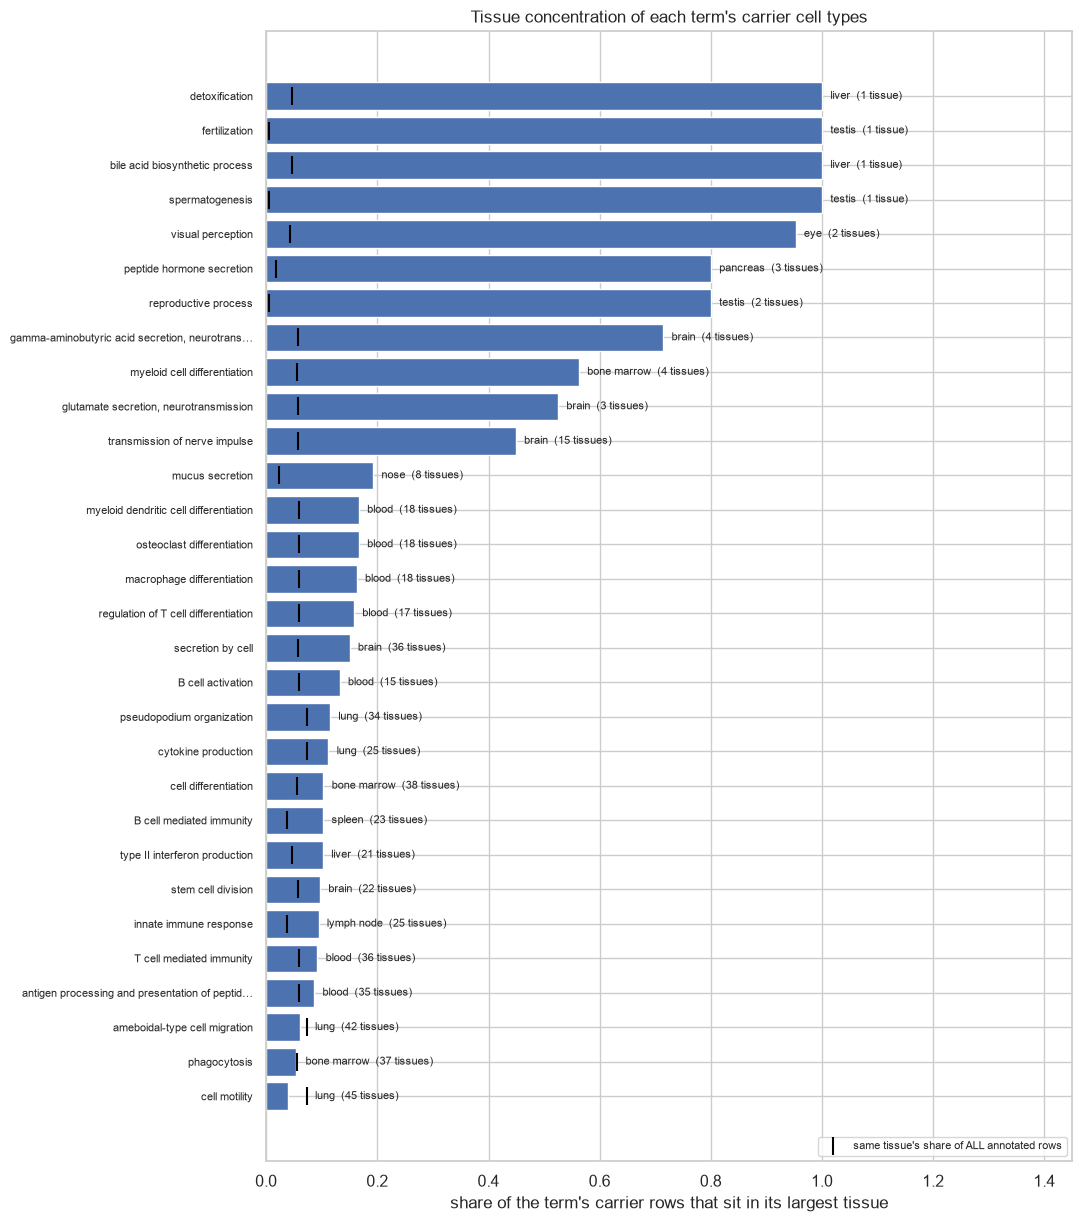

In [23]:
d = big.sort_values("top_tissue_share").reset_index(drop=True)
fig, ax = plt.subplots(figsize=(11, 0.34 * len(d) + 2.2))
ax.barh(range(len(d)), d["top_tissue_share"], color=COLORS["volume"])
ax.scatter(d["top_tissue_share_of_all_rows"], range(len(d)), marker="|", color="black", s=160, zorder=5, label="same tissue's share of ALL annotated rows")
for i, r in d.iterrows():
    ax.text(max(r["top_tissue_share"], r["top_tissue_share_of_all_rows"]) + 0.015, i,
            f"{r['top_tissue']}  ({r['n_tissues']} tissue{'s' if r['n_tissues'] != 1 else ''})", va="center", fontsize=8)
ax.set_yticks(range(len(d))); ax.set_yticklabels([short(l, 46) for l in d["label"]], fontsize=8)
ax.set_xlim(0, 1.45); ax.set_xlabel("share of the term's carrier rows that sit in its largest tissue")
ax.set_title("Tissue concentration of each term's carrier cell types")
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
save(fig, "19_tissue_purity")
plt.show()

## 20. Are some terms near-duplicates of each other?

Two heat maps over the same terms in the same order (clustered on the left map). **Jaccard** similarity is
|A ∩ B| / |A ∪ B| (0 = nothing shared, 1 = identical sets).
- **Left**: how similar the sets of genes are that each pair of terms was assigned to.
- **Right**: how similar the sets of cell types are that carry each pair of terms.
A dot marks pairs where one term is an ancestor or descendant of the other in the GO graph. Terms that light up in
both maps (and are GO-related) are close to the same signal counted more than once, which shrinks the effective
number of independent predictions.

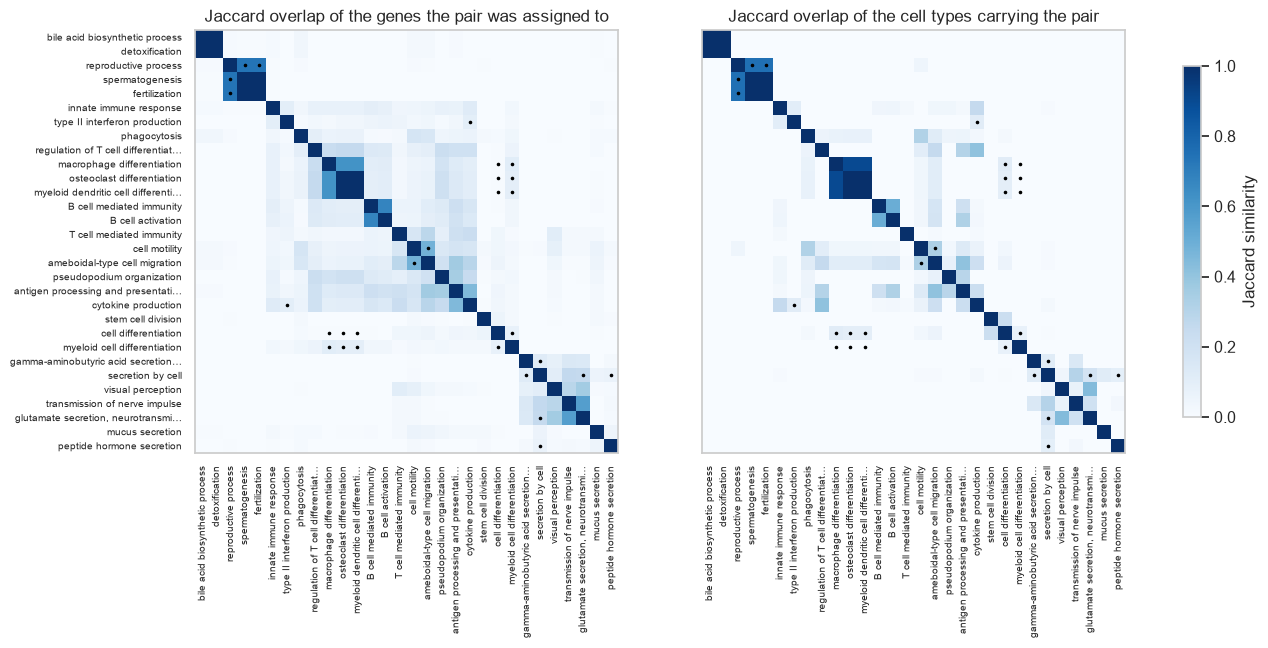

In [24]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform

term_ids = pairs["terms"]
sel = [term_ids.index(t) for t in big["go_id"]]
Jg = np.array(pairs["jaccard_assigned_genes"])[np.ix_(sel, sel)]
Jc = np.array(pairs["jaccard_carrier_cell_types"])[np.ix_(sel, sel)]
Rel = np.array(pairs["ontology_related"])[np.ix_(sel, sel)]
order = leaves_list(linkage(squareform(1 - Jg, checks=False), method="average"))
names = [short(big["label"].iloc[i], 34) for i in order]

fig, axes = plt.subplots(1, 2, figsize=(15, 7.6), sharey=True)
for ax, M, title in [(axes[0], Jg, "genes the pair was assigned to"), (axes[1], Jc, "cell types carrying the pair")]:
    im = ax.imshow(M[np.ix_(order, order)], cmap="Blues", vmin=0, vmax=1)
    ax.grid(False)
    ys, xs = np.where(Rel[np.ix_(order, order)] == 1)
    ax.scatter(xs, ys, s=10, color="black", marker=".")
    ax.set_xticks(range(len(names))); ax.set_xticklabels(names, rotation=90, fontsize=7)
    ax.set_title(f"Jaccard overlap of the {title}")
axes[0].set_yticks(range(len(names))); axes[0].set_yticklabels(names, fontsize=7)
fig.colorbar(im, ax=axes, shrink=0.6, label="Jaccard similarity")
save(fig, "20_term_redundancy")
plt.show()

## 21. Can every term even reach significance? (reachability)

For a gene with `n` expressing cell types in a background of `N`, and a term carried by `K` of them, the most
extreme overlap the hypergeometric test can see is `min(K, n)`; its p-value is the **floor** for that
(gene, term). If even the floor is above the g:SCS threshold, the term cannot be reported for that gene no matter
what the biology is. Here, per term: the share of genes for which it *can* reach significance (x) against how
often it was assigned (y). Terms far left are structurally handicapped; the grey markers are terms never assigned.

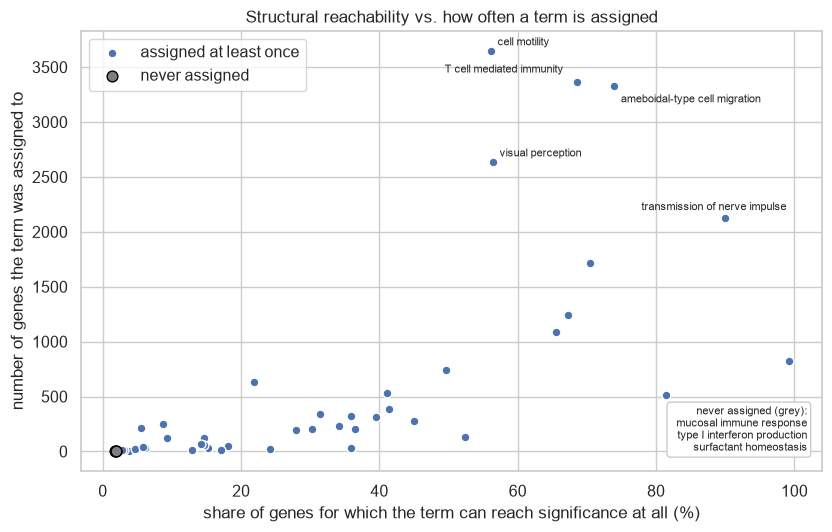

In [25]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
never = tp3["assigned"] == 0
ax.scatter(tp3.loc[~never, "frac_reachable"] * 100, tp3.loc[~never, "assigned"], s=40, color=COLORS["volume"], edgecolor="white", zorder=3, label="assigned at least once")
ax.scatter(tp3.loc[never, "frac_reachable"] * 100, tp3.loc[never, "assigned"], s=60, color=COLORS["no_match"], edgecolor="black", zorder=4, label="never assigned")
for (_, r), off in zip(tp3.nlargest(5, "assigned").iterrows(), [(5, 4), (-95, 7), (5, -12), (5, 4), (-60, 6)]):
    ax.annotate(short(r["label"], 30), (r["frac_reachable"] * 100, r["assigned"]), xytext=off, textcoords="offset points", fontsize=8)
ax.text(0.98, 0.04, "never assigned (grey):\n" + "\n".join("  " + l for l in tp3.loc[never, "label"]),
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8, bbox=dict(boxstyle="round", facecolor="white", edgecolor="#cccccc"))
ax.set_xlabel("share of genes for which the term can reach significance at all (%)")
ax.set_ylabel("number of genes the term was assigned to")
ax.set_title("Structural reachability vs. how often a term is assigned")
ax.legend()
fig.tight_layout()
save(fig, "21_reachability")
plt.show()

## 22. What kind of genes is each term assigned to?

- **Left**: for each frequently assigned term, the median expression breadth of the genes it was assigned to
  (breadth = share of cell types expressing the gene), against the median over all genes (vertical line). A term
  far to the left is mostly assigned to narrowly expressed genes; at the line, it is assigned to genes of
  ordinary breadth.
- **Right**: the single most common HGNC gene family among the genes the term was assigned to: its share of the
  term's genes, and how many times over-represented that is compared with its share among all genes (`enrichment`).

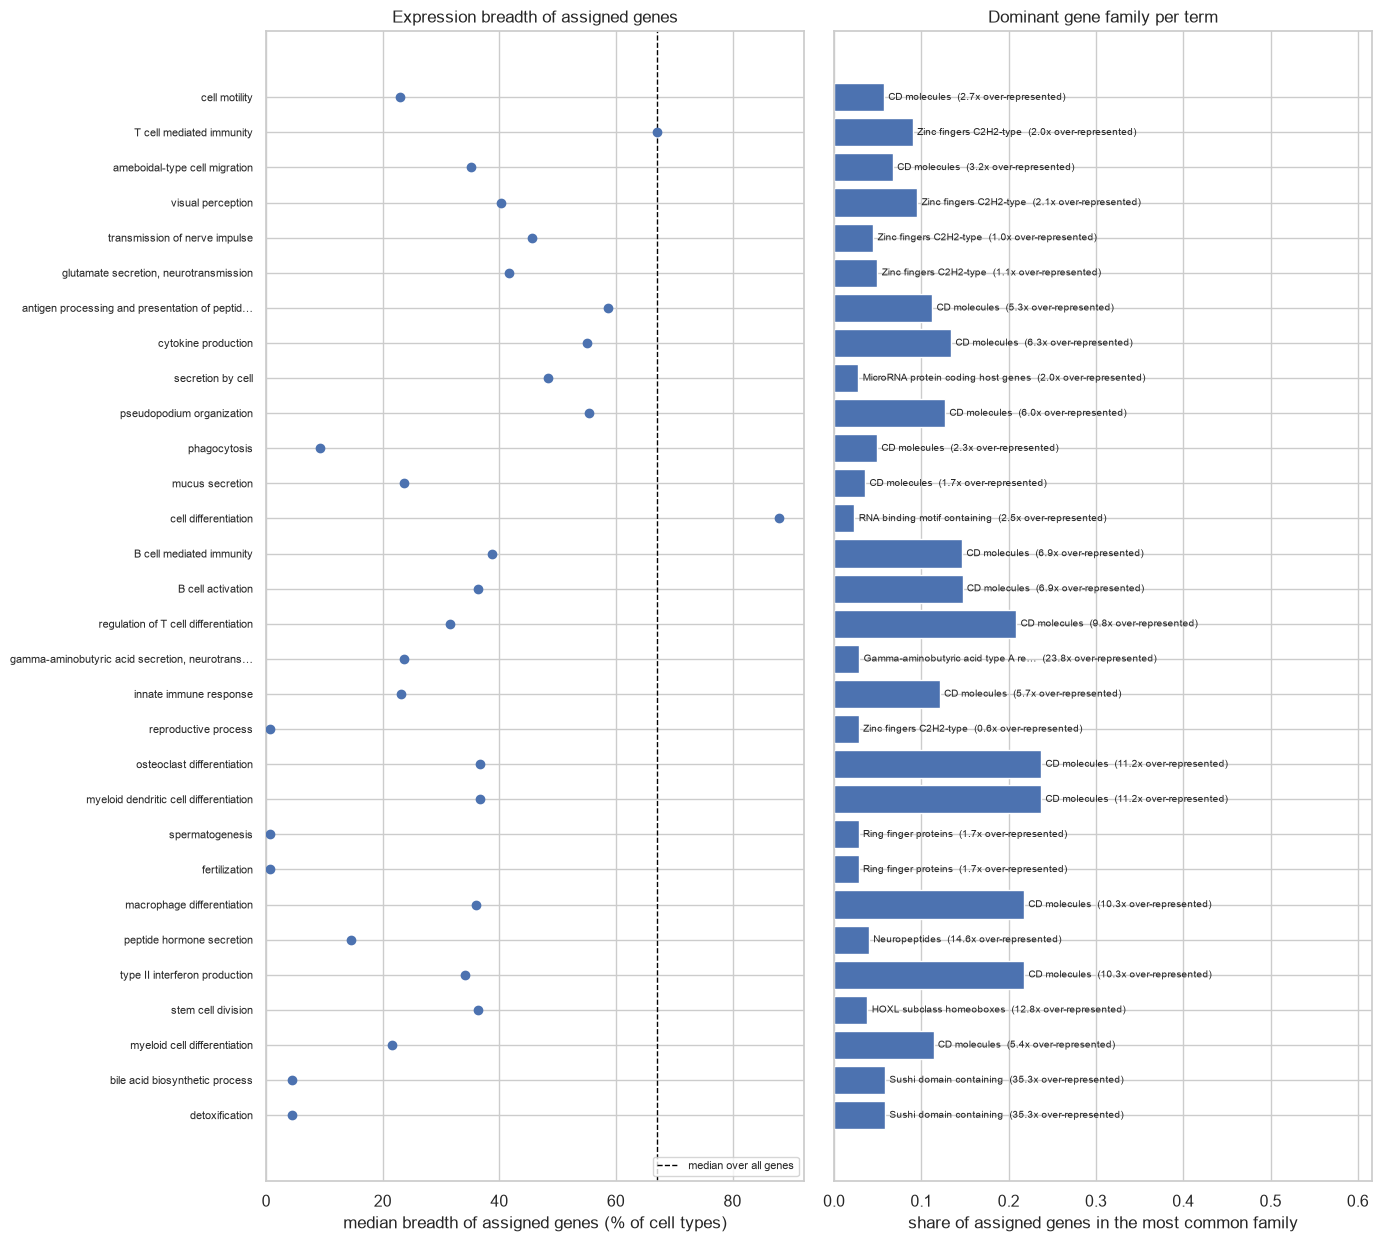

In [26]:
d = big.sort_values("assigned").reset_index(drop=True)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 0.34 * len(d) + 2.4), sharey=True)
ax1.scatter(d["median_breadth_assigned"] * 100, range(len(d)), color=COLORS["volume"], s=36, zorder=3)
ax1.axvline(ps["median_breadth_all_genes"] * 100, color="black", linestyle="--", linewidth=1, label="median over all genes")
ax1.set_yticks(range(len(d))); ax1.set_yticklabels([short(l, 46) for l in d["label"]], fontsize=8)
ax1.set_xlabel("median breadth of assigned genes (% of cell types)")
ax1.set_xlim(0, None); ax1.legend(loc="lower right", fontsize=8)
ax1.set_title("Expression breadth of assigned genes")

shares = [(r["top_families"][0] if r["top_families"] else None) for _, r in d.iterrows()]
ax2.barh(range(len(d)), [s["share_among_assigned"] if s else 0 for s in shares], color=COLORS["volume"])
for i, s in enumerate(shares):
    if s:
        ax2.text(s["share_among_assigned"] + 0.005, i, f"{short(s['family'], 34)}  ({s['enrichment']:.1f}x over-represented)", va="center", fontsize=7.5)
ax2.set_xlim(0, max([s["share_among_assigned"] for s in shares if s]) * 2.6)
ax2.set_xlabel("share of assigned genes in the most common family")
ax2.set_title("Dominant gene family per term")
fig.tight_layout()
save(fig, "22_gene_profile_per_term")
plt.show()

## Part 3 summary

Each bullet gives what the plot shows and what it means for the project (358 annotated cell types, 1,469
annotated CL|UBERON rows).

- **Plot 17, assigned count against cell-type frequency.** Terms carried by more cell types are assigned more
  often (Spearman ρ = 0.80 across 52 terms; 0.76 among the 49 ever assigned). This replaces an earlier chat figure
  that used the per-gene `term_size`.
  *For us:* what arm 1 outputs is driven largely by how many cell types a term has, which is a property of the
  vocabulary and the test, not of the gene. The distribution of assigned terms is a fingerprint we can compare
  with arm 2: if the LLM's output follows the same size pattern, it is mostly echoing the statistics.
- **Plot 18, precision against base rate.** The five most-assigned terms make up 56% of all assignments and only
  4.7% of those match. Ameboidal-type cell migration, phagocytosis and cell differentiation are right about as
  often as blind assignment (lift 1.0x, 1.2x, 0.9x); type II interferon production, assigned to 193 genes, never
  matched. Precision is negatively related to carrier count (ρ = -0.32).
  *For us:* the terms arm 1 uses most are the least informative, so its overall match rate is pulled down by a few
  frequent terms and a per-term view is more honest than one number. For arm 2, a high share of the same
  frequent terms in its output would be a warning sign.
- **Plot 19, tissue concentration.** Four terms sit entirely in one tissue (liver or testis), visual perception
  is 95% eye, and the three most-assigned terms spread over 36-45 tissues. More tissue-concentrated terms have
  higher lift (ρ = 0.58 over 30 terms); the best are fertilization (22x), bile acid biosynthetic process (13x),
  spermatogenesis (12x) and B cell mediated immunity (11x).
  *For us:* the best-performing terms may be tissue detectors, not process detectors: finding testis-specific
  expression gives "spermatogenesis" without any insight into the process. Good scores on these terms are weaker
  evidence than they look, so results should be checked with those terms removed.
- **Plot 20, term redundancy.** Detoxification with bile acid biosynthetic process, the trio reproductive process
  / spermatogenesis / fertilization, and the trio macrophage / osteoclast / myeloid dendritic cell
  differentiation overlap almost completely, in both the genes they were assigned to and the cell types that carry
  them. The two overlap maps have nearly the same structure.
  *For us:* the 52 terms are fewer independent predictions than they seem, and gene-to-term assignment follows
  which cell types terms share. Counting matches per term double-counts the same signal, so gene-level scores
  (did the gene get any match) or terms grouped into clusters are safer for comparing arms.
- **Plot 21, reachability.** The share of genes for which a term can reach significance at all runs from 1.8% to
  99.1% and goes with how often it is assigned (ρ = 0.85). The three terms never assigned (mucosal immune
  response, type I interferon production, surfactant homeostasis) can reach significance for about 2% of genes.
  *For us:* part of the vocabulary is out of reach for the statistical test regardless of biology, which the LLM
  is not bound by. If arm 2 uses those terms, that is something the baseline cannot do, and the vocabulary's
  minimum term size is a design choice worth revisiting.
- **Plot 22, kind of genes per term.** The median breadth of assigned genes runs from under 1% (reproductive
  process, spermatogenesis, fertilization) to 88% (cell differentiation), against 67% for all genes. In 16 of 30
  frequent terms the dominant family is "CD molecules", usually several times over-represented.
  *For us:* terms act as proxies for gene types: narrow tissue-specific genes, or immune families. A term showing
  up for a gene may tell us the gene belongs to that group rather than carry process-level information, which is
  the main limit on how much the baseline's output can mean for gene function.

**Taken together:** arm 1 assigns a few broad, widely carried terms very often and those are close to
uninformative. Where it does well, it uses narrow, tissue-specific terms that overlap heavily and may reflect
tissue identity. For arm 2 the useful checks are its term distribution against this one, its use of terms arm 1
cannot reach, and its scores with the tissue-specific terms removed.

# Part 4 — the matches that are more specific than the truth

A prediction can be more specific than a true term of the gene (the true term is an ancestor of the prediction,
a "downward" relation). The question here is what these predictions look like when they have *only* that
relation, i.e. when every true term they relate to is more general than they are. A prediction can also relate to
two different true terms at once: more specific than one and more general than another. The classification used
throughout the notebook labels such a prediction "upward" whichever is closer, so those cases are separated out
below instead of being hidden inside the upward group.

Produced by `scripts/analyze_arm1_downward_split.py` from the arm 1 cache.

In [27]:
ds = json.loads((RESULTS_DIR / "arm1_downward_split__all.json").read_text())
dsplit = pd.DataFrame(ds["rows"])
dcounts = ds["counts"]
assert dcounts["only_down"] == t["n_downward_total"], "only-downward group must equal Part 1's downward count"
print({k: v for k, v in dcounts.items()})

{'no_match': 25143, 'only_down': 644, 'up_only': 750, 'exact': 197, 'both_up_closer_or_equal': 34, 'both_down_closer': 11}


## 23. How many of the downward matches have only that relation?

Every significant prediction that is more specific than at least one true term (689 in all), split by whether it
ALSO is more general than another true term of the same gene:
- **only more specific** -- every true term it relates to is more general than it. This is the group Part 1
  counts as "downward".
- **also more general, downward relation closer** -- it relates both ways and the more-specific relation is the
  shorter one (fewer GO edges). Counted as "upward" in Part 1.
- **also more general, upward relation closer or equal** -- it relates both ways and the more-general relation is
  the shorter one or ties. Counted as "upward" in Part 1.

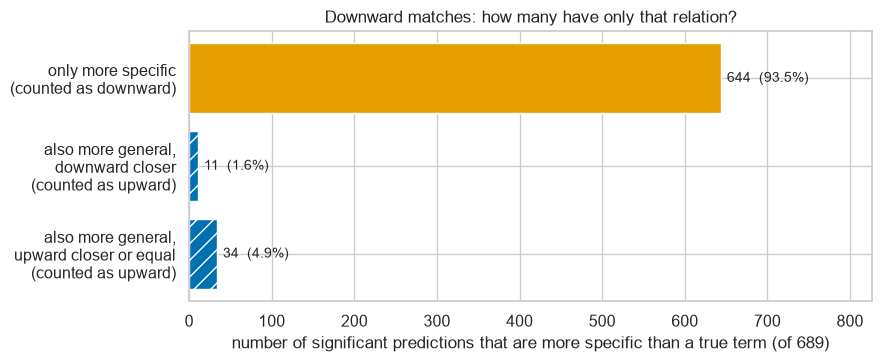

In [28]:
grp = pd.Series({
    "only more specific\n(counted as downward)": dcounts["only_down"],
    "also more general,\ndownward closer\n(counted as upward)": dcounts["both_down_closer"],
    "also more general,\nupward closer or equal\n(counted as upward)": dcounts["both_up_closer_or_equal"],
})
n_down_rel = grp.sum()
fig, ax = plt.subplots(figsize=(9, 3.8))
bars = ax.barh(grp.index[::-1], grp.values[::-1], color=[COLORS["downward"], COLORS["upward"], COLORS["upward"]][::-1])
bars[0].set_hatch("//"); bars[1].set_hatch("//")  # the two groups that Part 1 labels "upward" are hatched
for bar, v in zip(bars, grp.values[::-1]):
    ax.text(bar.get_width() + n_down_rel * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{v:,}  ({v / n_down_rel:.1%})", va="center", fontsize=10)
ax.set_xlim(0, n_down_rel * 1.2)
ax.set_xlabel(f"number of significant predictions that are more specific than a true term (of {n_down_rel:,})")
ax.set_title("Downward matches: how many have only that relation?")
fig.tight_layout()
save(fig, "23_downward_only_split")
plt.show()

## 24. How far apart are the predicted and the true term, in information content?

For the group that is more specific than the truth and has only that relation, the information-content (IC)
distance: IC(predicted) minus IC(true term), where the true term is the nearest ancestor of the prediction in GO
edges. IC = -ln(fraction of genes carrying the term), so a distance of 1 means the prediction is about 2.7x
rarer than the true term, 2 about 7x, 4 about 55x.
- **Left**: histogram of that IC distance, with the median marked.
- **Right**: the same distance split by how many GO edges separate the two terms, to show how well edges and IC
  agree.

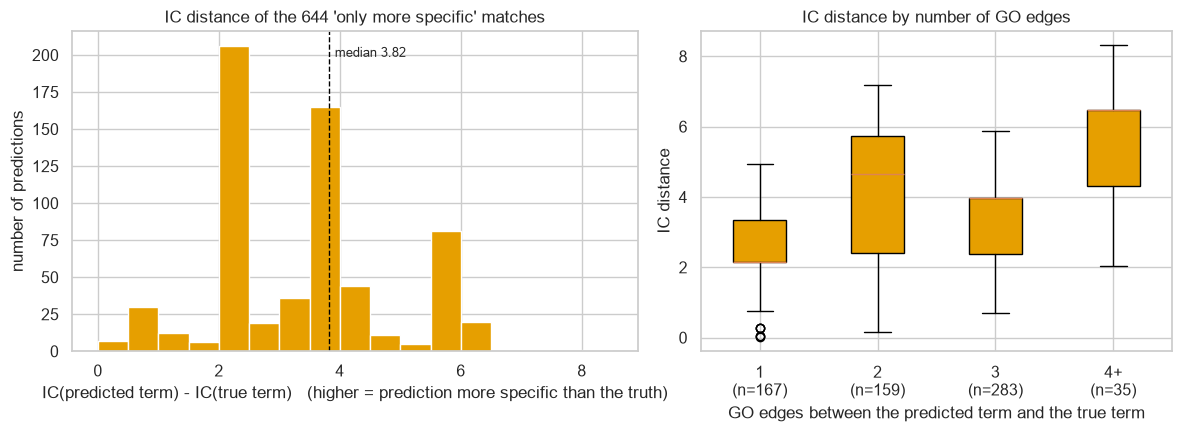

count    644.00
mean       3.45
std        1.48
min        0.03
25%        2.36
50%        3.82
75%        4.10
max        8.31


In [29]:
od = dsplit[dsplit["group"] == "only_down"].copy()
med = od["ic_distance"].median()
od["edges"] = od["d_down"].clip(upper=4).map(lambda d: "4+" if d >= 4 else str(int(d)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5), gridspec_kw={"width_ratios": [1.2, 1]})
ax1.hist(od["ic_distance"], bins=np.arange(0, od["ic_distance"].max() + 0.5, 0.5), color=COLORS["downward"], edgecolor="white")
ax1.axvline(med, color="black", linestyle="--", linewidth=1)
ax1.text(med + 0.1, ax1.get_ylim()[1] * 0.95, f"median {med:.2f}", fontsize=9, va="top")
ax1.set_xlabel("IC(predicted term) - IC(true term)   (higher = prediction more specific than the truth)")
ax1.set_ylabel("number of predictions")
ax1.set_title(f"IC distance of the {len(od):,} 'only more specific' matches")

order_e = ["1", "2", "3", "4+"]
data = [od.loc[od["edges"] == e, "ic_distance"] for e in order_e]
bp = ax2.boxplot(data, tick_labels=[f"{e}\n(n={len(d)})" for e, d in zip(order_e, data)], patch_artist=True, showfliers=True)
for patch in bp["boxes"]:
    patch.set_facecolor(COLORS["downward"])
ax2.set_xlabel("GO edges between the predicted term and the true term")
ax2.set_ylabel("IC distance")
ax2.set_title("IC distance by number of GO edges")
fig.tight_layout()
save(fig, "24_downward_ic_distance")
plt.show()
print(od["ic_distance"].describe().round(2).to_string())

In [30]:
# The spikes in the histogram are repeated (prediction, true term) pairs, so list the most common pairs.
pairs_tbl = (od.groupby(["label", "true_label"])
               .agg(n=("gene_id", "size"), median_ic_distance=("ic_distance", "median"), median_edges=("d_down", "median"))
               .sort_values("n", ascending=False))
print(f"{len(od):,} matches come from {len(pairs_tbl)} distinct (predicted term, true term) pairs over {od['gene_id'].nunique()} genes;"
      f" the top 3 pairs cover {pairs_tbl['n'].head(3).sum() / len(od):.0%}, the top 10 cover {pairs_tbl['n'].head(10).sum() / len(od):.0%}")
print("most common true terms:", od["true_label"].value_counts().head(5).to_dict())
pairs_tbl.head(10).round(2)

644 matches come from 74 distinct (predicted term, true term) pairs over 529 genes; the top 3 pairs cover 45%, the top 10 cover 74%
most common true terms: {'immune response': 261, 'chemical synaptic transmission': 74, 'cell migration': 51, 'adaptive immune response': 45, 'cell-cell signaling': 27}


,,n,median_ic_distance,median_edges
label,true_label,,,
T cell mediated immunity,immune response,157,3.97,3.0
B cell mediated immunity,immune response,84,2.36,3.0
ameboidal-type cell migration,cell migration,51,2.16,1.0
"glutamate secretion, neurotransmission",chemical synaptic transmission,49,5.74,2.0
T cell mediated immunity,adaptive immune response,39,2.41,2.0
"gamma-aminobutyric acid secretion, neurotransmission",chemical synaptic transmission,25,5.74,2.0
"glutamate secretion, neurotransmission","synaptic transmission, glutamatergic",19,3.33,1.0
innate immune response,immune response,18,0.83,1.0
"glutamate secretion, neurotransmission",cell-cell signaling,17,6.47,4.0


## 25. Which true terms do the downward matches attach to, and how general are they?

Plots 23-24 looked at the predictions. This looks at the other end: the gene's true GO term each 'only more
specific' prediction is matched to (the nearest true ancestor, as in Plot 24).
- **Left**: cumulative share of terms by information content (IC; low = general, high = specific). Orange: the
  true terms that received at least one such match. Grey: every distinct term that appears as a direct
  annotation of any gene analysed, as the reference for what a typical true term looks like.
- **Right**: of all the distinct true terms in each IC range, how many received at least one such match.

45 distinct true terms receive the 644 'only more specific' matches (47 if every true ancestor is counted); 12 of them receive a single match
median IC: 3.74 for those true terms vs 7.94 for all 10,103 distinct direct true terms; share of terms with IC < 3: 31% vs 0.8%


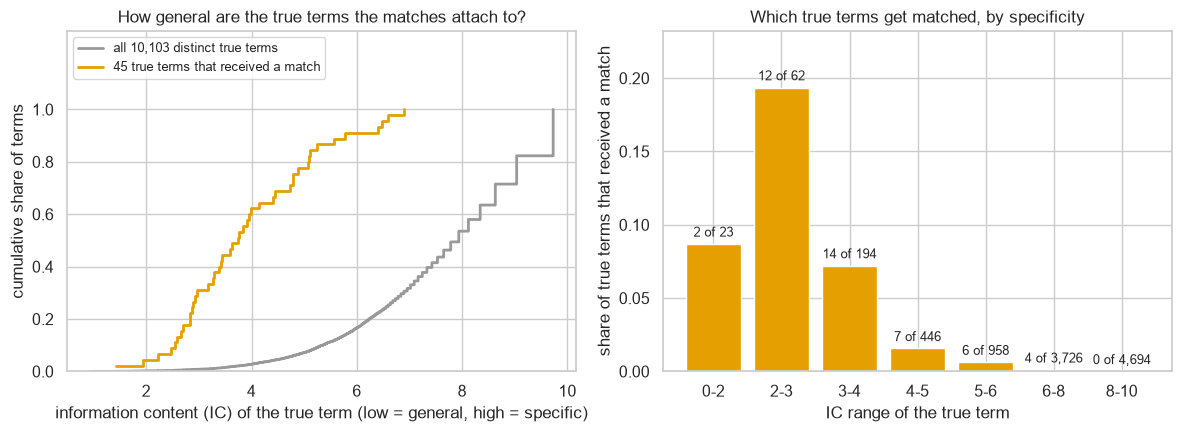

In [31]:
all_true = pd.DataFrame(ds["all_true_terms"])
hit_ids = set(od["true_term"])
all_true["hit"] = all_true["go_id"].isin(hit_ids)
hit = all_true[all_true["hit"]]
by_true = (od.groupby("true_term")
             .agg(label=("true_label", "first"), matches=("gene_id", "size"), genes=("gene_id", "nunique"),
                  predicted_terms=("go_id", "nunique"), ic=("ic_true", "first"))
             .sort_values("matches", ascending=False))
n_any = len({t for lst in od["all_ancestor_true_terms"] for t in lst})
print(f"{len(by_true)} distinct true terms receive the {len(od):,} 'only more specific' matches "
      f"({n_any} if every true ancestor is counted); {(by_true['matches'] == 1).sum()} of them receive a single match")
print(f"median IC: {hit['ic'].median():.2f} for those true terms vs {all_true['ic'].median():.2f} for all "
      f"{len(all_true):,} distinct direct true terms; share of terms with IC < 3: "
      f"{(hit['ic'] < 3).mean():.0%} vs {(all_true['ic'] < 3).mean():.1%}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
for df, color, lab in [(all_true, "#999999", f"all {len(all_true):,} distinct true terms"),
                       (hit, COLORS["downward"], f"{len(hit)} true terms that received a match")]:
    x = np.sort(df["ic"].to_numpy())
    ax1.step(x, np.arange(1, len(x) + 1) / len(x), where="post", color=color, linewidth=2, label=lab)
ax1.set_xlabel("information content (IC) of the true term (low = general, high = specific)")
ax1.set_ylabel("cumulative share of terms")
ax1.set_title("How general are the true terms the matches attach to?")
ax1.set_ylim(0, 1.3)  # free band above the curves for the legend
ax1.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])  # a share cannot exceed 1
ax1.legend(loc="upper left", fontsize=9)

bins = [0, 2, 3, 4, 5, 6, 8, 10]
all_true["bin"] = pd.cut(all_true["ic"], bins)
tab = all_true.groupby("bin", observed=True).agg(n_terms=("go_id", "size"), n_hit=("hit", "sum"))
xx = range(len(tab))
ax2.bar(xx, tab["n_hit"] / tab["n_terms"], color=COLORS["downward"])
for i, (n, h) in enumerate(zip(tab["n_terms"], tab["n_hit"])):
    ax2.text(i, h / n + 0.005, f"{h} of {n:,}", ha="center", fontsize=9)
ax2.set_xticks(list(xx)); ax2.set_xticklabels([f"{iv.left:g}-{iv.right:g}" for iv in tab.index])
ax2.set_xlabel("IC range of the true term")
ax2.set_ylabel("share of true terms that received a match")
ax2.set_ylim(0, (tab["n_hit"] / tab["n_terms"]).max() * 1.2)
ax2.set_title("Which true terms get matched, by specificity")
fig.tight_layout()
save(fig, "25_true_term_ic")
plt.show()

## 26. How concentrated are the matches on a few true terms?

The 15 true terms that receive the most 'only more specific' matches, with how many matches and genes each
accounts for, how many different predicted terms attach to it, and its IC.

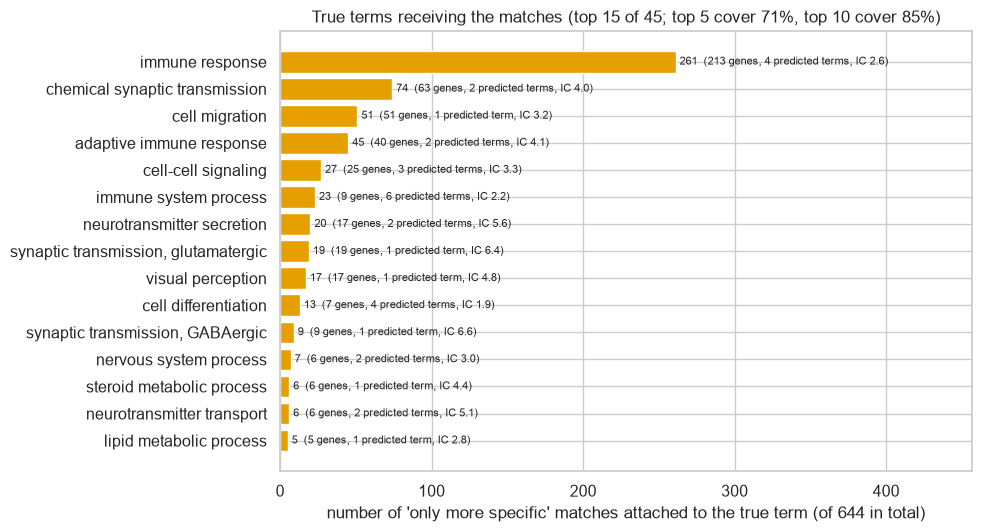

In [32]:
top = by_true.head(15)[::-1]
fig, ax = plt.subplots(figsize=(10, 5.5))
bars = ax.barh([short(l, 44) for l in top["label"]], top["matches"], color=COLORS["downward"])
for bar, (_, r) in zip(bars, top.iterrows()):
    ax.text(bar.get_width() + by_true["matches"].max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{r['matches']}  ({r['genes']} genes, {r['predicted_terms']} predicted term{'s' if r['predicted_terms'] != 1 else ''}, IC {r['ic']:.1f})",
            va="center", fontsize=8)
ax.set_xlim(0, by_true["matches"].max() * 1.75)
ax.set_xlabel(f"number of 'only more specific' matches attached to the true term (of {len(od):,} in total)")
ax.set_title(f"True terms receiving the matches (top 15 of {len(by_true)}; top 5 cover "
             f"{by_true['matches'].head(5).sum() / len(od):.0%}, top 10 cover {by_true['matches'].head(10).sum() / len(od):.0%})")
fig.tight_layout()
save(fig, "26_true_term_concentration")
plt.show()

## Part 4 summary

- **Plot 23, how many downward matches have only that relation.** Of the 689 predictions that are more specific
  than at least one true term, 644 (93.5%) have only that relation. 45 also are more general than another true
  term of the same gene (11 with the more-specific relation closer, 34 with the more-general one closer or tied),
  and the classification labels those upward.
  *For us:* the mixed cases are too few to change anything. The 644 downward matches are exactly the "only more
  specific" group, so Parts 1-3 already describe it, and a different tie-break between the two relations would
  move at most 11 predictions.
- **Plot 24, IC distance between predicted and true term.** These predictions are more specific than the truth by
  a median of 3.82 IC units (middle half 2.36 to 4.10, range 0.03 to 8.31); 92% are at least 2 units more
  specific (about 7x rarer) and 25% at least 4 (about 55x). More GO edges go with a larger IC distance on average,
  but not cleanly: 3 edges have a lower median distance than 2 edges.
  *For us:* a downward "match" is a much narrower claim than the true annotation, not a near miss. The histogram
  is spiky because the matches are not 644 independent cases: they come from 74 distinct (prediction, true term)
  pairs over 529 genes, and the top 3 pairs cover 45%. The true terms involved are very general ("immune response"
  alone is the true term for 261 of the 644), so a typical downward match is an immune-cell term such as "T cell
  mediated immunity" counted against a gene known only as "immune response". Such a match shows the gene is
  immune-related, which is real information, but it is nowhere near the specific claim the prediction makes, so
  downward matches should be reported separately from exact and upward ones (together with Plot 16, where most of
  them turned out to be chance-level) and the true terms that make them possible should be named when results
  are reported.
- **Plot 25, the true terms the matches attach to.** All 644 matches attach to only 45 distinct true terms (47 if
  every true ancestor is counted), and 12 of those 45 receive a single match. They are far more general than a
  typical true term: median IC 3.74 against 7.94 for all 10,103 distinct direct true terms, and 31% of them have
  an IC below 3 against 0.8% of all true terms. Of the true terms with IC up to 3, 14 of 85 receive a match; of
  the 4,694 with IC above 8, none does.
  *For us:* downward matches are only possible against general true terms, because a very specific true term has
  almost no descendants among the 52 candidates. The size of the downward group is set by how many genes carry one
  of a few general terms, not by the method, which is why it stays close to chance (Plot 16).
- **Plot 26, concentration on a few true terms.** The top 5 true terms cover 71% of the matches and the top 10
  cover 85%. "Immune response" alone takes 261 matches (213 genes), followed by chemical synaptic transmission
  (74), cell migration (51), adaptive immune response (45) and cell-cell signaling (27); "immune system process"
  receives matches from 6 different predicted terms.
  *For us:* the downward result is three or four themes (immune, synaptic, migration), not broad coverage of gene
  function. Reporting it as a count of matches overstates how much of GO is being recovered; reporting it as the
  number of distinct true terms reached (45 of 10,103) gives a more honest picture.